# 세그먼트 통합 정리본

**목적**  
기존 세그먼트 노트북에 흩어져 있던 프로토스타, 슈퍼노바, 코멧, 위성, 성단 분석 코드를 하나의 실행 가능한 노트북으로 통합한다.

**통합 기준**
- 공통 라이브러리, 폰트, 데이터 로드는 한 번만 수행한다.
- 각 세그먼트는 독립 변수명을 사용해 Run All 시 변수 충돌을 줄인다.
- 마크다운 구성은 슈퍼노바 최종 정리본의 형식을 참고해 목적, 산식, 기준, 결과 확인 순서로 정리한다.

**세그먼트 구성**
1. 성단: 소속/크루 단위 영입 우선순위 분석
2. 프로토스타: 작은 체급 대비 반응이 강한 성장형 후보군
3. 위성: 개인형 고화력 후보 및 영입제한 후보 분류
4. 슈퍼노바: 대중성, 팬덤체급, 방송화력을 갖춘 최상위 후보군
5. 코멧: 방송 체급 대비 외부 팬덤 유입 가능성이 큰 후보군

## 1. 라이브러리 및 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.cm as cm
from pathlib import Path

# 한글 폰트 설정: 사용 가능한 폰트 중 먼저 발견되는 것을 적용
font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font in font_candidates:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.max_open_warning"] = 0

# 데이터 경로
DATA_PATH = "../data/final_softcone_for_team.csv"

df = pd.read_csv(DATA_PATH)
df_raw = df.copy()

print("DATA_PATH:", DATA_PATH)
print("데이터 크기:", df.shape)
display(df.head())
df.columns.tolist()

DATA_PATH: ../data/final_softcone_for_team.csv
데이터 크기: (11157, 18)


,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,소속
0,탬탬버린,CHZZK,a7e175625fdea5a7d98428302b7aa57f,2025.01.01 ~ 2026.03.31,308659,2769,5923,2346,23115,13532,17075004,6876167,4.4,-13.9,0,537000,46191,NaN
1,텐코 시부키,CHZZK,64d76089fba26b180d9c9e48a32600d9,2025.01.01 ~ 2026.03.31,222276,2368,7255,4660,34645,16465,14216251,6737178,-0.7,4.1,78000,204000,252724,스텔라이브
2,아리사,CHZZK,4de764d9dad3b25602284be6db3ac647,2025.01.01 ~ 2026.03.31,84836,4218,7123,3100,12994,8066,11904276,6932861,-0.8,-6.2,7028,77600,30431,에스더
3,아라하시 타비,CHZZK,a6c4ddb09cdb160478996007bff35296,2025.01.01 ~ 2026.03.31,232937,2409,6976,4840,28568,12483,11350960,6733563,-0.1,4.0,89000,230000,252724,스텔라이브
4,고세구,SOOP,gosegu2,2025.01.01 ~ 2026.03.31,199696,1558,95063,17283,39102,23877,10855404,5905590,8.2,9.8,0,545000,573411,이세계아이돌


['스트리머명',
 '플랫폼',
 '채널ID',
 '집계기간_내_최초_방송일',
 '최고_팔로워',
 '총_방송시간',
 '6분_최고채팅',
 '6분_평균채팅_최댓값',
 '최고_시청자',
 '평균_시청자_최댓값',
 '뷰어십',
 '도네이션',
 '유튜브_유입지수',
 '팬덤지수',
 'X_팔로워',
 '유튜브_구독자',
 '팬카페_가입자',
 '소속']

## 2. 공통 유틸 함수

세그먼트별 점수 계산에서 반복되는 정규화, 로그 보정, 그래프 스타일 처리를 공통 함수로 정리한다.

In [2]:
def ensure_numeric(data, cols, fill_value=0):
    for col in cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce").fillna(fill_value)
    return data

def safe_minmax(series, feature_range=(0, 100)):
    s = pd.to_numeric(series, errors="coerce")
    min_v = s.min()
    max_v = s.max()
    if pd.isna(min_v) or pd.isna(max_v) or max_v == min_v:
        return pd.Series(feature_range[0], index=series.index, dtype="float64")
    scaled = (s - min_v) / (max_v - min_v)
    low, high = feature_range
    return scaled * (high - low) + low

def robust_minmax(series, use_log=True, use_winsorize=True, lower_q=0.001, upper_q=0.999, fill_value=0):
    s = pd.to_numeric(series, errors="coerce")
    if use_log:
        s = np.log1p(s.clip(lower=0))
    if use_winsorize:
        lo = s.quantile(lower_q)
        hi = s.quantile(upper_q)
        s = s.clip(lower=lo, upper=hi)
    return safe_minmax(s, feature_range=(0, 1)).fillna(fill_value)

def add_log_zsum(data, cols, out_col):
    data[out_col] = 0.0
    for col in cols:
        if col not in data.columns:
            continue
        log_s = np.log1p(pd.to_numeric(data[col], errors="coerce").fillna(0).clip(lower=0))
        std = log_s.std()
        if pd.notna(std) and std != 0:
            data[out_col] += (log_s - log_s.mean()) / std
    return data

def clean_affiliation(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if text.lower() in ["nan", "none", "null", "-", "없음", "무소속"]:
        return ""
    return text

def draw_horizontal_bar(df, label_col, value_col, title, color="#4F7CAC", xlabel="점수", figsize=(10, 7)):
    plot_df = df.sort_values(value_col, ascending=True).copy()
    plt.figure(figsize=figsize, facecolor="white")
    ax = plt.gca()
    ax.set_facecolor("white")
    plt.barh(plot_df[label_col], plot_df[value_col], color=color, height=0.72)
    for i, value in enumerate(plot_df[value_col]):
        plt.text(value + 0.5, i, f"{value:.1f}", va="center", fontsize=9)
    plt.title(title, fontsize=14, fontweight="bold", pad=14)
    plt.xlabel(xlabel)
    plt.ylabel(label_col)
    plt.grid(axis="x", alpha=0.18)
    plt.grid(axis="y", visible=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_alpha(0.25)
    ax.tick_params(axis="y", length=0)
    plt.tight_layout()
    plt.show()

## 3. 성단(Constellation) 산식 정의

성단은 스트리머 개인이 아니라 **소속/크루 단위의 영입 우선순위**를 보는 세그먼트이다.

### 최종 산식

**영입우선 점수 = 플랫폼체급 점수 + ARPU 점수 + 대중성 점수**

### 세부 점수
- **플랫폼체급 점수**: 뷰어십, 도네이션, 시청자, 팔로워, 채팅 지표의 로그 Z-score 합산
- **ARPU 점수**: 도네이션 / 뷰어십 기반 팬덤 지갑 화력
- **외부인기 점수**: X 팔로워, 유튜브 구독자, 팬카페 가입자 기반 외부 팬덤 규모
- **대중성 점수**: 외부인기 점수를 뷰어십 규모로 보정한 가성비 대중성

In [3]:
constellation_df = df_raw.copy()
constellation_df["소속_clean"] = constellation_df["소속"].apply(clean_affiliation)
constellation_df = constellation_df[constellation_df["소속_clean"] != ""].copy()

constellation_blacklist = [
    "왁타버스", "스코시즘", "하나비", "회사계정", "졸업",
    "크로아", "트윌릿", "브이레코드", "브이레이", "브이레이어", "모아이대학교"
]
constellation_df = constellation_df[~constellation_df["소속_clean"].isin(constellation_blacklist)].copy()

constellation_num_cols = [
    "최고_팔로워", "6분_최고채팅", "6분_평균채팅_최댓값", "최고_시청자",
    "평균_시청자_최댓값", "뷰어십", "도네이션", "X_팔로워", "유튜브_구독자", "팬카페_가입자"
]
constellation_df = ensure_numeric(constellation_df, constellation_num_cols)

agg_rules = {
    "스트리머명": "count",
    "최고_팔로워": "sum",
    "6분_최고채팅": "max",
    "6분_평균채팅_최댓값": "mean",
    "최고_시청자": "max",
    "평균_시청자_최댓값": "max",
    "뷰어십": "sum",
    "도네이션": "sum",
    "X_팔로워": "sum",
    "유튜브_구독자": "sum",
    "팬카페_가입자": "max",
}

constellation_grouped = constellation_df.groupby("소속_clean").agg(agg_rules).reset_index()
constellation_grouped = constellation_grouped.rename(columns={
    "소속_clean": "소속",
    "스트리머명": "멤버수",
    "최고_팔로워": "합계_최고팔로워",
    "6분_최고채팅": "최댓값_6분최고채팅",
    "6분_평균채팅_최댓값": "평균_6분평균채팅",
    "최고_시청자": "최댓값_최고시청자",
    "평균_시청자_최댓값": "최댓값_평균시청자",
    "뷰어십": "합계_뷰어십",
    "도네이션": "합계_도네이션",
    "X_팔로워": "합계_X팔로워",
    "유튜브_구독자": "합계_유튜브구독자",
    "팬카페_가입자": "최댓값_팬카페가입자",
})

constellation_grouped["ARPU_원본"] = constellation_grouped["합계_도네이션"] / constellation_grouped["합계_뷰어십"].replace(0, 1)
constellation_grouped["ARPU_점수"] = safe_minmax(np.log1p(constellation_grouped["ARPU_원본"]))

internal_cols = [
    "합계_뷰어십", "합계_도네이션", "최댓값_최고시청자", "최댓값_평균시청자",
    "합계_최고팔로워", "최댓값_6분최고채팅", "평균_6분평균채팅"
]
constellation_grouped = add_log_zsum(constellation_grouped, internal_cols, "플랫폼_체급_Z합산")
constellation_grouped["플랫폼체급_점수"] = safe_minmax(constellation_grouped["플랫폼_체급_Z합산"])

external_cols = ["합계_X팔로워", "합계_유튜브구독자", "최댓값_팬카페가입자"]
constellation_grouped = add_log_zsum(constellation_grouped, external_cols, "외부인기_Z합산")
constellation_grouped["외부인기_점수"] = safe_minmax(constellation_grouped["외부인기_Z합산"])

denom = np.log1p(constellation_grouped["합계_뷰어십"]).replace(0, 1)
constellation_grouped["가성비대중성_원본"] = constellation_grouped["외부인기_점수"] / denom
constellation_grouped["대중성_점수"] = safe_minmax(constellation_grouped["가성비대중성_원본"])

constellation_grouped["영입우선_원본"] = (
    constellation_grouped["플랫폼체급_점수"]
    + constellation_grouped["ARPU_점수"]
    + constellation_grouped["대중성_점수"]
)
constellation_grouped["영입우선_점수"] = safe_minmax(constellation_grouped["영입우선_원본"])

constellation_score_cols = ["플랫폼체급_점수", "ARPU_점수", "외부인기_점수", "대중성_점수", "영입우선_점수"]
constellation_grouped[constellation_score_cols] = constellation_grouped[constellation_score_cols].fillna(0).round(0).astype(int)

constellation_result_cols = [
    "소속", "멤버수", "합계_뷰어십", "합계_도네이션", "합계_최고팔로워",
    "플랫폼체급_점수", "ARPU_점수", "외부인기_점수", "대중성_점수", "영입우선_점수"
]
constellation_result = (
    constellation_grouped[constellation_result_cols]
    .sort_values("영입우선_점수", ascending=False)
    .reset_index(drop=True)
)

constellation_result.head(20)

,소속,멤버수,합계_뷰어십,합계_도네이션,합계_최고팔로워,플랫폼체급_점수,ARPU_점수,외부인기_점수,대중성_점수,영입우선_점수
0,이소로피아,3,189774,2852993,16378,54,72,64,84,100
1,리레볼루션,4,924754,5254413,118394,69,44,83,96,99
2,셀리브,6,38574,437206,11028,52,64,62,93,99
3,바라바라,6,56549,709730,9789,51,66,62,90,98
4,크레슈,4,136602,2787678,10624,53,81,52,71,96
5,오토메테일,4,35465,727658,4370,43,81,52,80,95
6,스테이브,4,56842,949190,6021,49,75,55,80,95
7,싸이코드,5,2629047,7951943,222916,79,28,87,94,94
8,이엔아이,4,18083,325094,3585,37,77,54,88,94
9,몽상컴퍼니,7,789706,8703730,39291,67,63,60,71,93


### 성단 타겟 15팀 확인

기존 노트북에서 사용한 타겟 15팀을 전체 생태계 기준 점수표에서 별도로 확인한다.

In [4]:
target_15 = [
    "바라바라", "리레볼루션", "이소로피아", "셀리브", "오토메테일",
    "크레슈", "스테이브", "이엔아이", "싸이코드", "몽상컴퍼니",
    "에이더스", "루미니아", "리베르타", "에델리안", "리액트케이알"
]

constellation_target15 = (
    constellation_result[constellation_result["소속"].isin(target_15)]
    .sort_values("영입우선_점수", ascending=False)
    .reset_index(drop=True)
)

display(constellation_target15)

,소속,멤버수,합계_뷰어십,합계_도네이션,합계_최고팔로워,플랫폼체급_점수,ARPU_점수,외부인기_점수,대중성_점수,영입우선_점수
0,이소로피아,3,189774,2852993,16378,54,72,64,84,100
1,리레볼루션,4,924754,5254413,118394,69,44,83,96,99
2,셀리브,6,38574,437206,11028,52,64,62,93,99
3,바라바라,6,56549,709730,9789,51,66,62,90,98
4,크레슈,4,136602,2787678,10624,53,81,52,71,96
5,오토메테일,4,35465,727658,4370,43,81,52,80,95
6,스테이브,4,56842,949190,6021,49,75,55,80,95
7,싸이코드,5,2629047,7951943,222916,79,28,87,94,94
8,이엔아이,4,18083,325094,3585,37,77,54,88,94
9,몽상컴퍼니,7,789706,8703730,39291,67,63,60,71,93


### 성단 시각화

타겟 15팀과 전체 TOP 15를 기준으로 주요 점수를 확인한다.

C:\Users\SS\AppData\Local\Temp\ipykernel_3064\2789532310.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


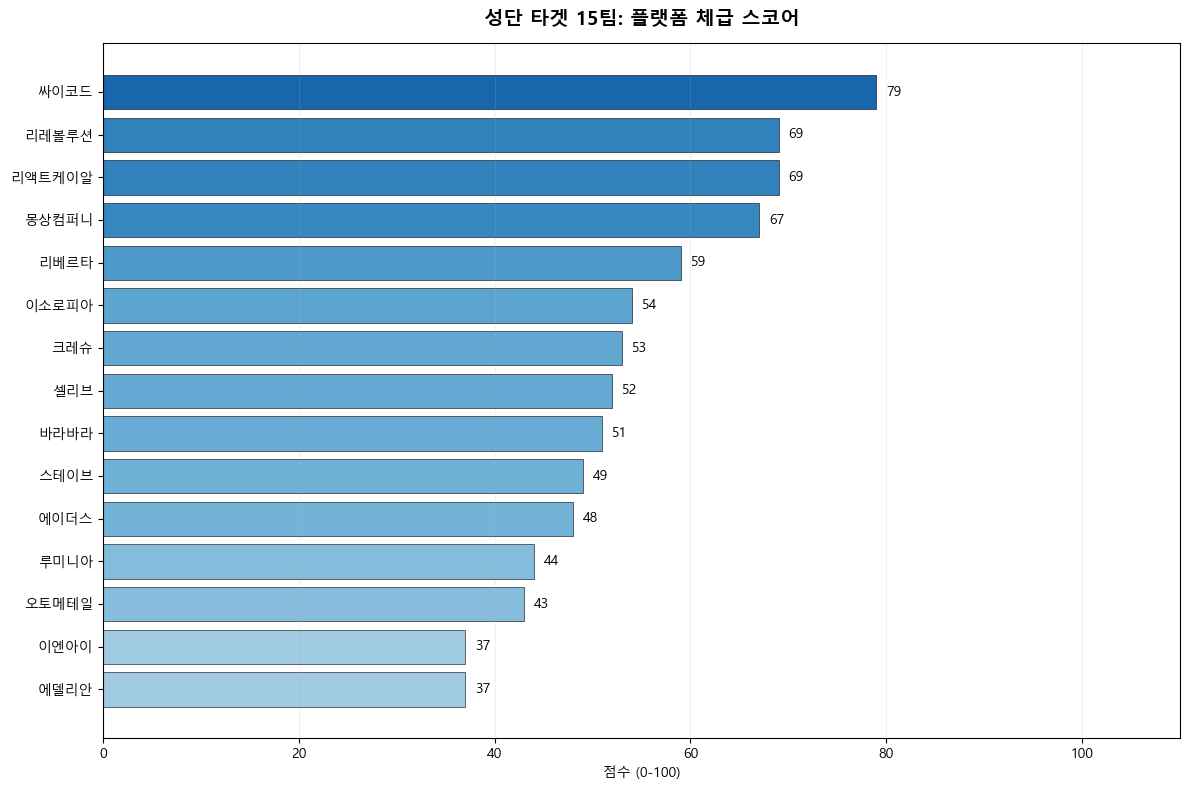

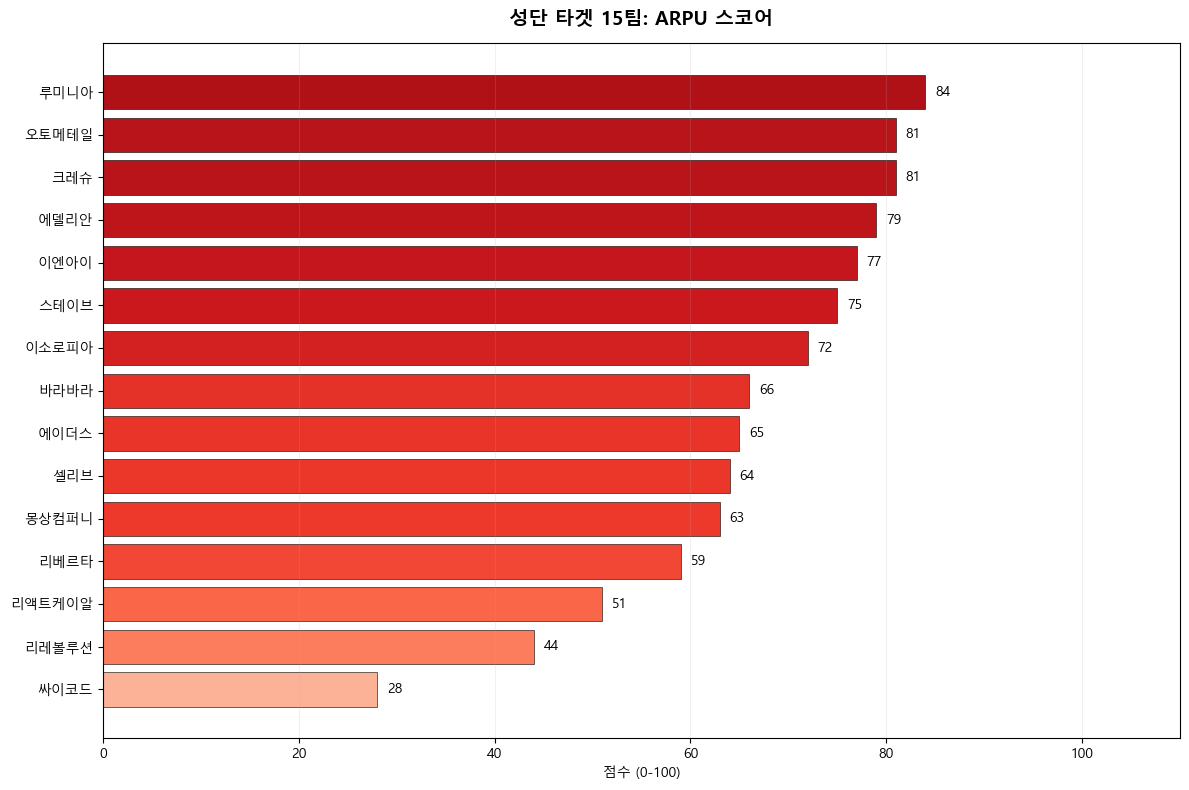

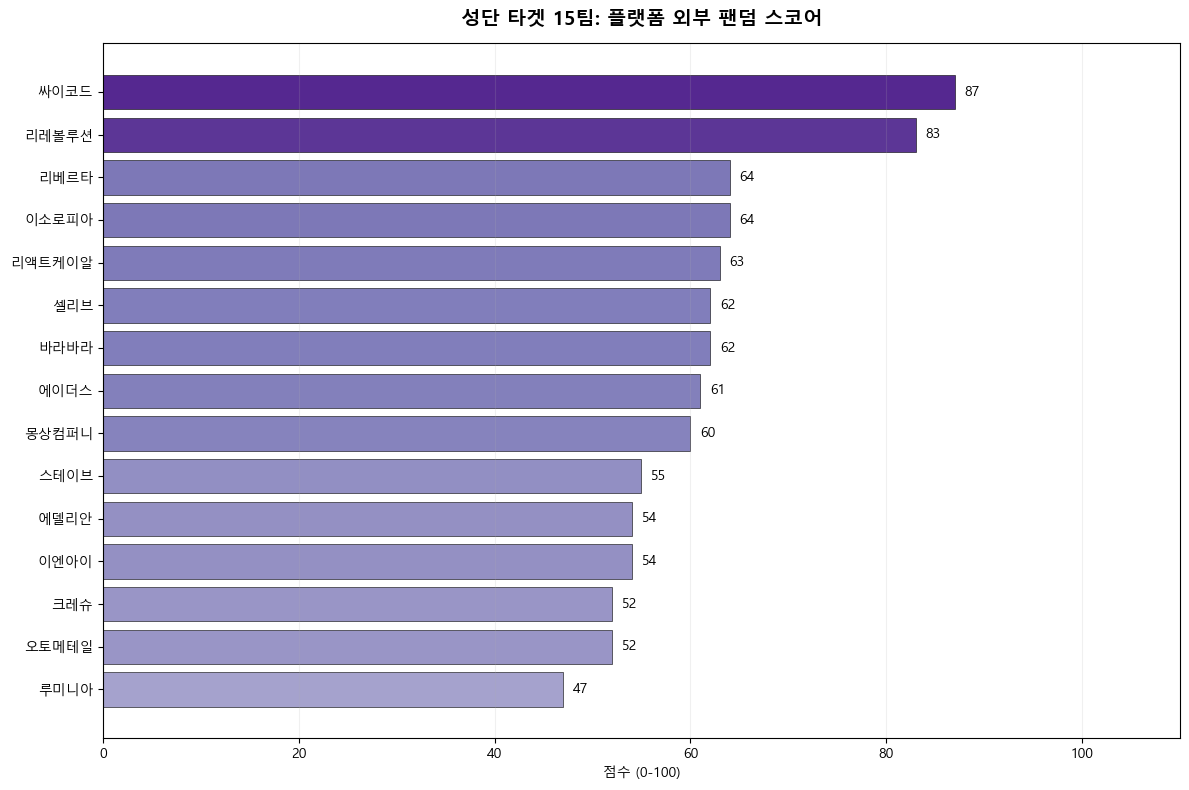

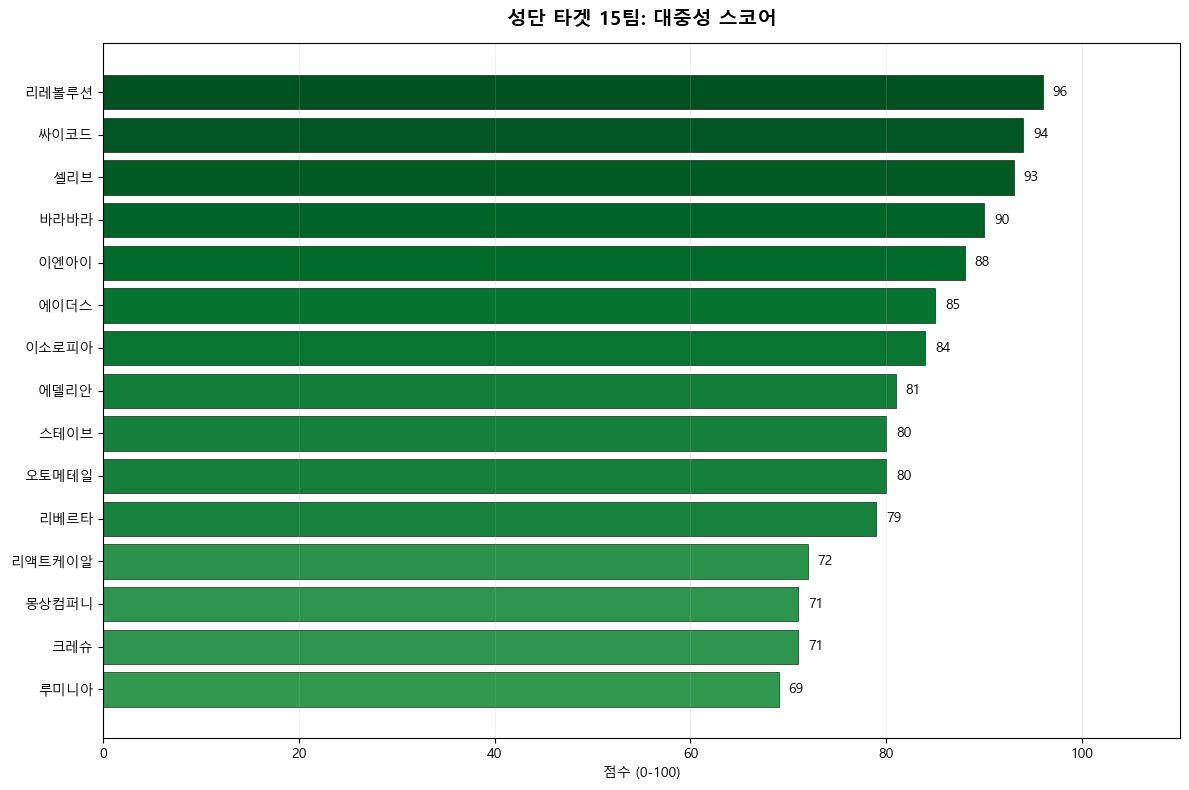

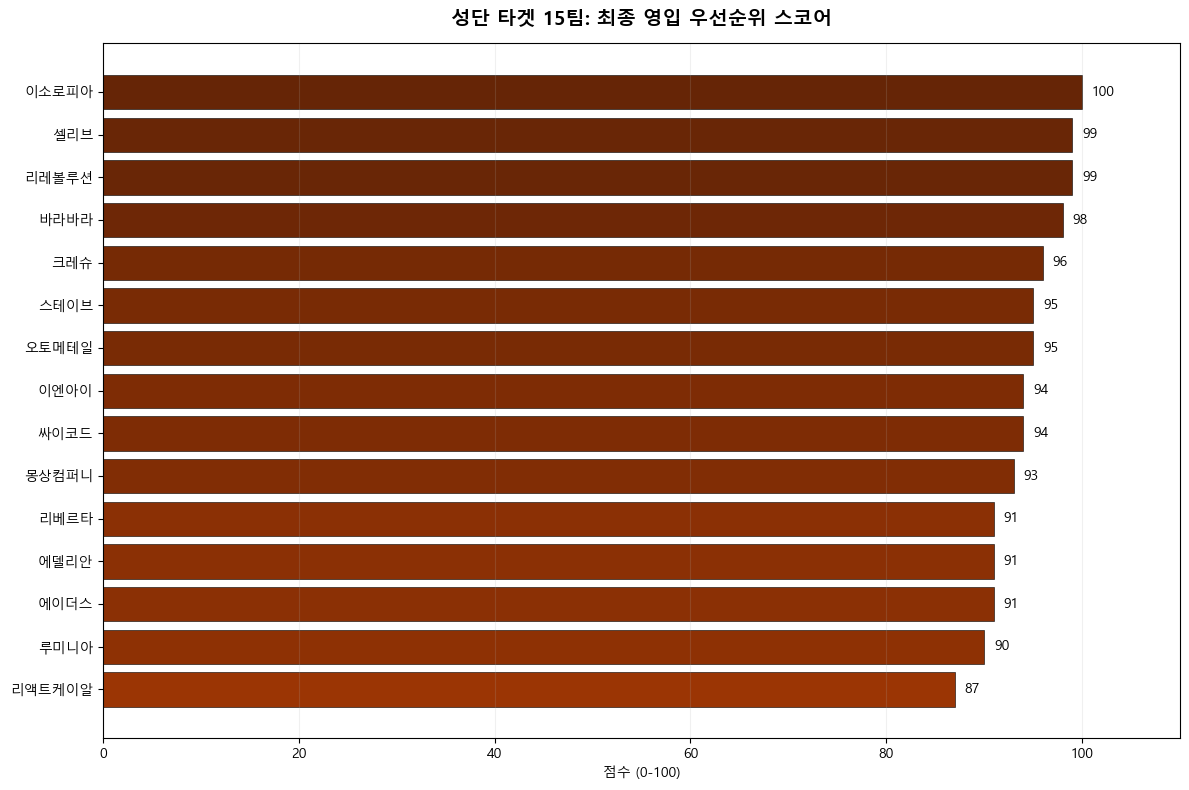

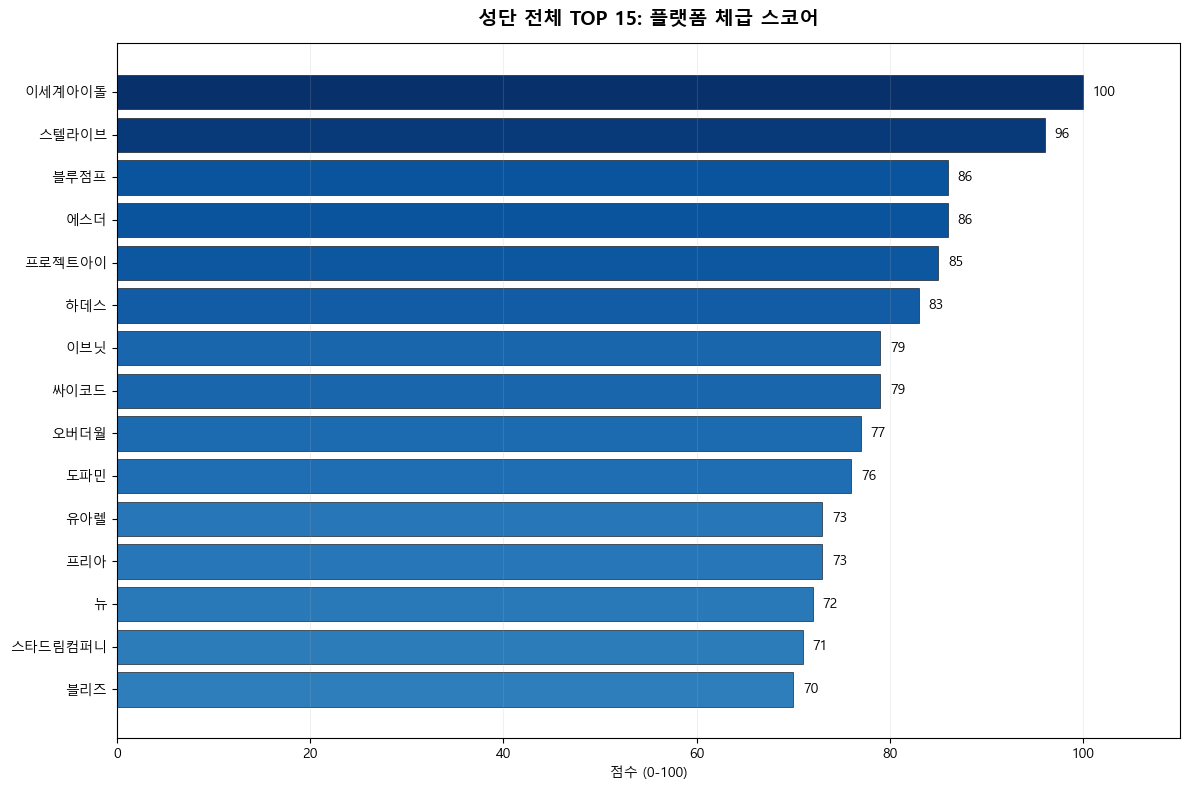

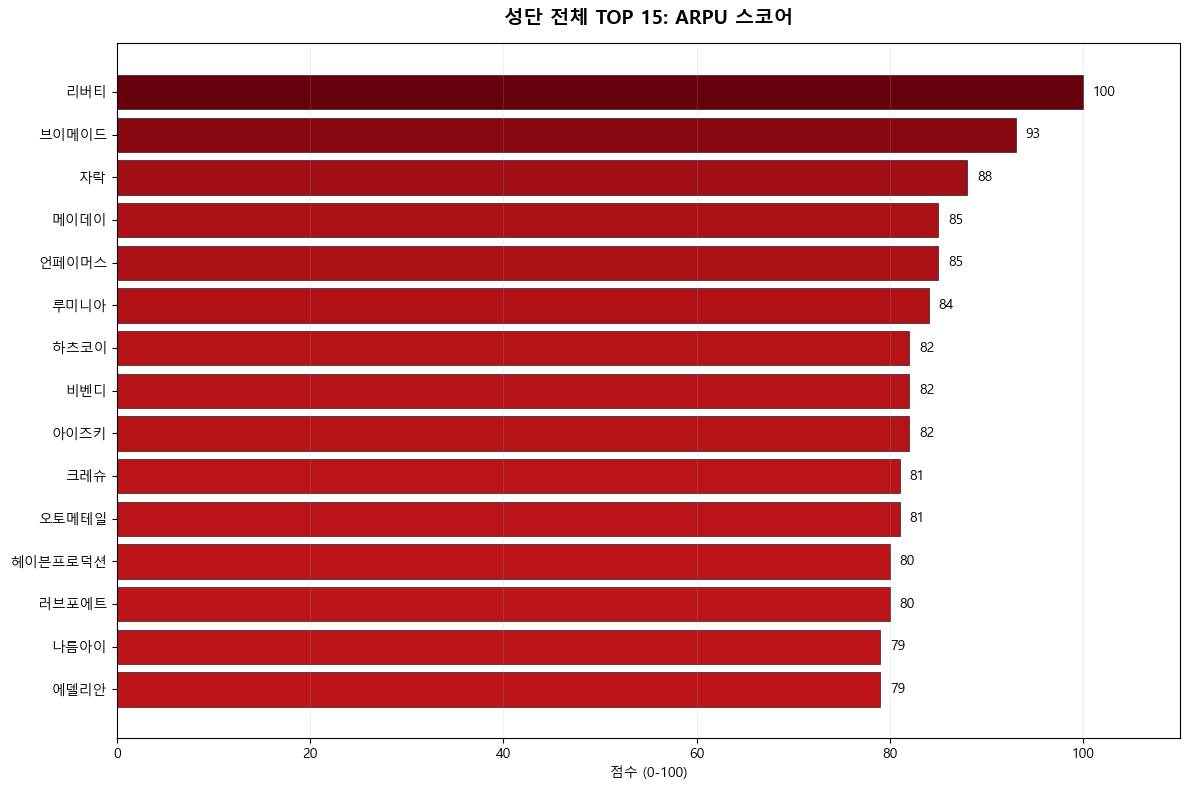

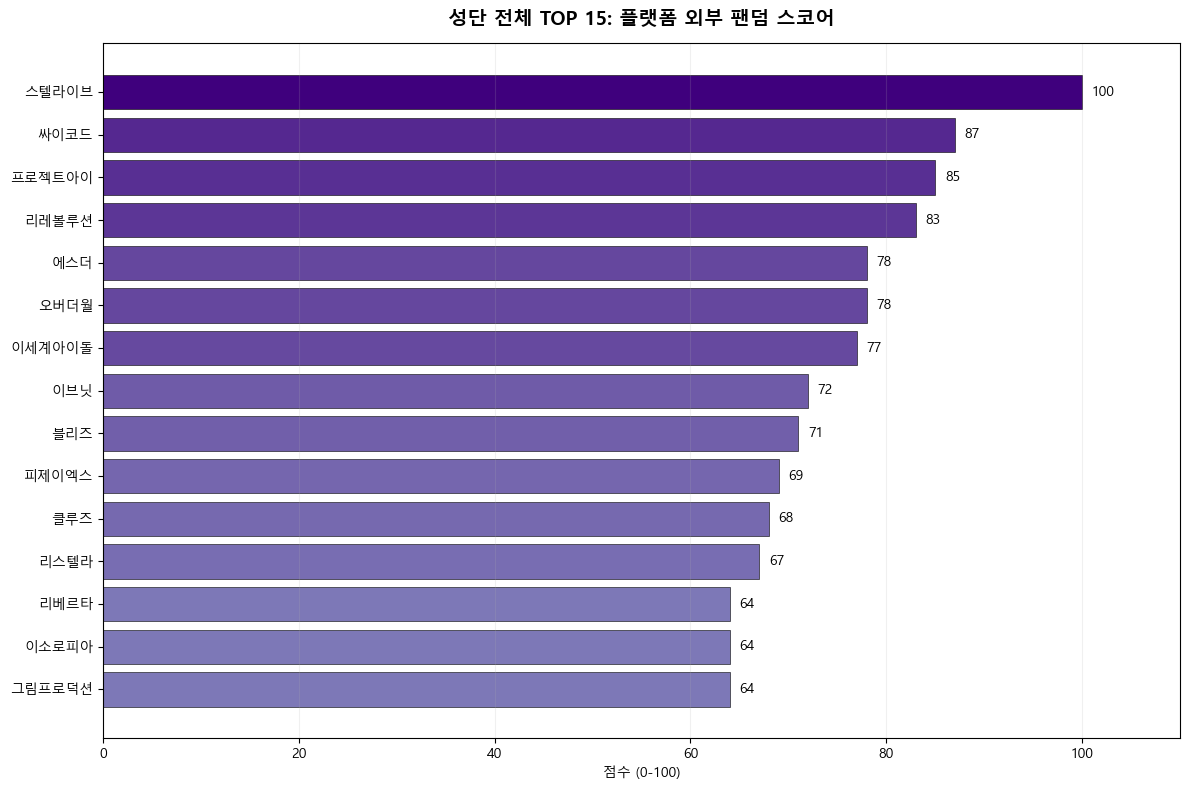

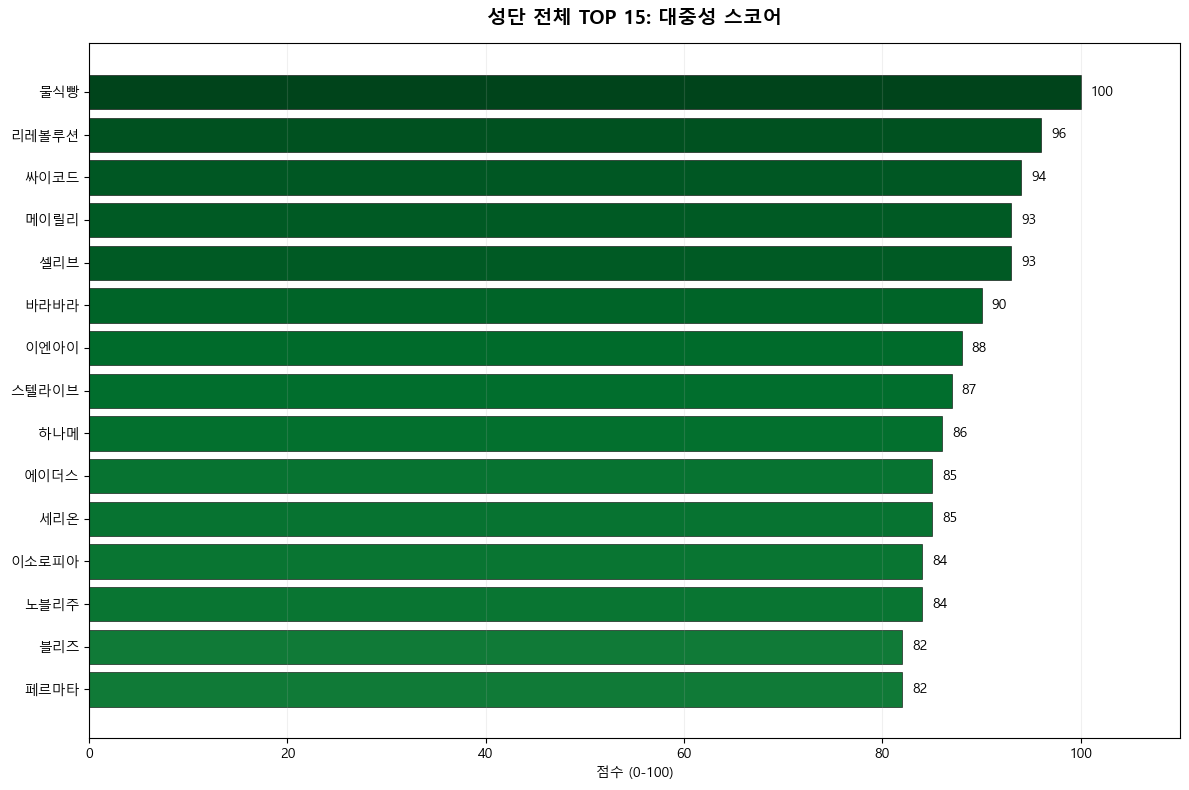

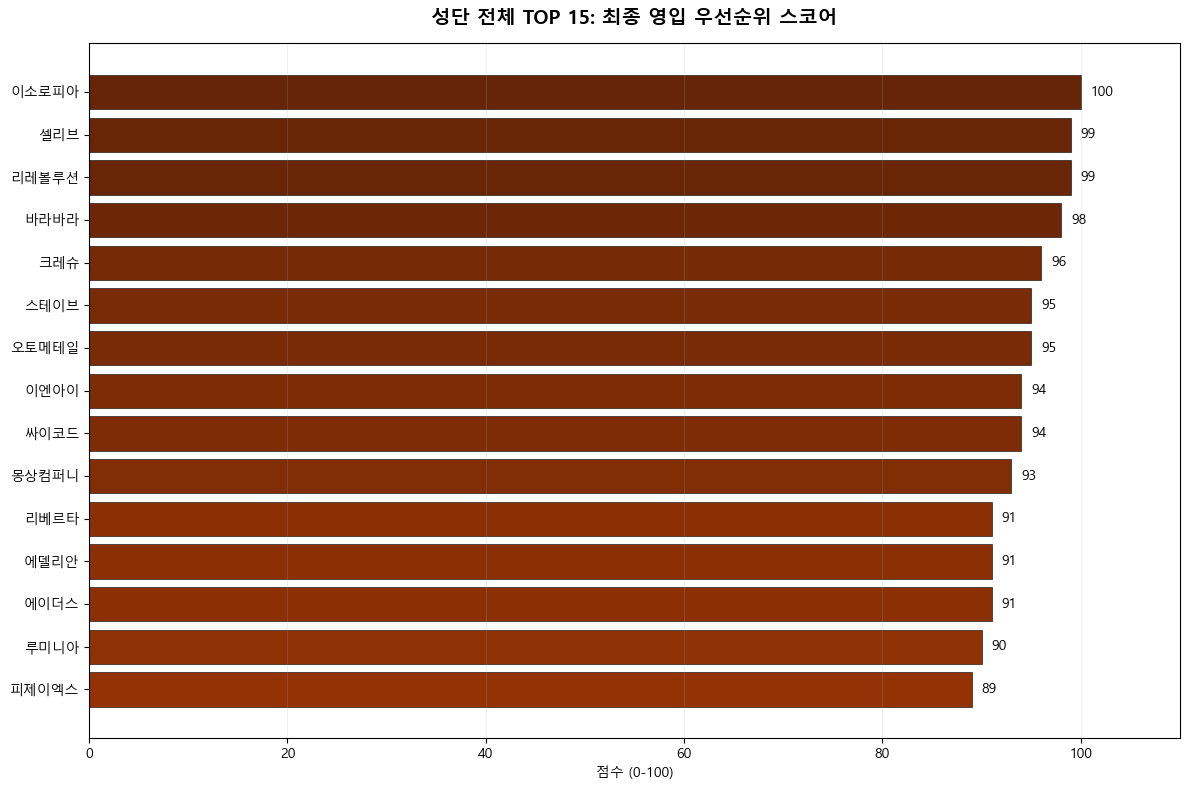

In [5]:
def draw_constellation_chart(df, col_name, title, cmap_name="Blues"):
    plot_df = df.sort_values(col_name, ascending=True).copy()
    cmap = cm.get_cmap(cmap_name)
    colors = cmap(plot_df[col_name] / 100)
    plt.figure(figsize=(12, 8), facecolor="white")
    plt.barh(plot_df["소속"], plot_df[col_name], color=colors, edgecolor="black", linewidth=0.4)
    for i, value in enumerate(plot_df[col_name]):
        plt.text(value + 1, i, f"{value}", va="center", fontsize=10)
    plt.title(title, fontsize=14, fontweight="bold", pad=14)
    plt.xlabel("점수 (0-100)")
    plt.xlim(0, 110)
    plt.grid(axis="x", alpha=0.18)
    plt.tight_layout()
    plt.show()

constellation_chart_specs = [
    ("플랫폼체급_점수", "플랫폼 체급 스코어", "Blues"),
    ("ARPU_점수", "ARPU 스코어", "Reds"),
    ("외부인기_점수", "플랫폼 외부 팬덤 스코어", "Purples"),
    ("대중성_점수", "대중성 스코어", "Greens"),
    ("영입우선_점수", "최종 영입 우선순위 스코어", "YlOrBr"),
]

for col_name, label, cmap_name in constellation_chart_specs:
    draw_constellation_chart(
        constellation_target15,
        col_name,
        f"성단 타겟 15팀: {label}",
        cmap_name,
    )

for col_name, label, cmap_name in constellation_chart_specs:
    draw_constellation_chart(
        constellation_result.nlargest(15, col_name),
        col_name,
        f"성단 전체 TOP 15: {label}",
        cmap_name,
    )

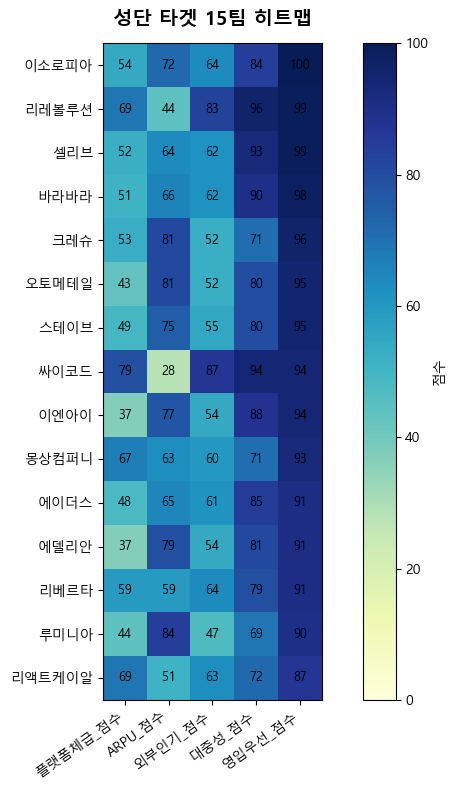

In [6]:
heatmap_cols = ["플랫폼체급_점수", "ARPU_점수", "외부인기_점수", "대중성_점수", "영입우선_점수"]
heatmap_df = constellation_target15.set_index("소속")[heatmap_cols].sort_values("영입우선_점수", ascending=False)

plt.figure(figsize=(11, 8), facecolor="white")
im = plt.imshow(heatmap_df.values, cmap="YlGnBu", vmin=0, vmax=100)
plt.xticks(range(len(heatmap_cols)), heatmap_cols, rotation=35, ha="right")
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        plt.text(j, i, f"{int(heatmap_df.iloc[i, j])}", ha="center", va="center", fontsize=9)

plt.title("성단 타겟 15팀 히트맵", fontsize=14, fontweight="bold", pad=14)
plt.colorbar(im, fraction=0.046, pad=0.04, label="점수")
plt.tight_layout()
plt.show()

## 4. 프로토스타(Protostar) 산식 정의

프로토스타는 **외형 규모는 아직 작지만 실제 방송 반응과 팬덤 밀도가 높은 성장형 후보군**을 찾는 세그먼트이다.

### 최종 산식

**프로토스타 점수 = 뷰어십 20% + 채팅 15% + 평균 시청자 25% + 팬덤지수 15% + 시간당 뷰어십 15% + 팔로워 대비 시청자 10%**

### 후보군 기준
- **상위 10% 이상**: S급 후보군
- **상위 30% 이상**: A급 후보군
- **나머지**: 기타 후보군

In [7]:
proto_df = df_raw.copy()

proto_numeric_cols = [
    "최고_팔로워", "뷰어십", "총_방송시간", "평균_시청자_최댓값",
    "최고_시청자", "6분_최고채팅", "팬덤지수"
]
proto_df = ensure_numeric(proto_df, proto_numeric_cols)

# 개인세/중소형 후보를 보기 위한 기본 정제
proto_df = proto_df[
    (proto_df["최고_팔로워"] > 0)
    & (proto_df["뷰어십"] > 0)
    & (proto_df["총_방송시간"] > 0)
    & (proto_df["평균_시청자_최댓값"] <= proto_df["최고_시청자"])
].copy()

proto_df["팔로워대비_시청자"] = (
    proto_df["평균_시청자_최댓값"] / proto_df["최고_팔로워"].replace(0, np.nan)
) * 100
proto_df["채팅_뷰어십_비율"] = proto_df["6분_최고채팅"] / proto_df["뷰어십"].replace(0, np.nan)

proto_df = proto_df[
    (proto_df["팔로워대비_시청자"] <= 70)
    & (proto_df["채팅_뷰어십_비율"] <= 0.1)
    & (proto_df["총_방송시간"] >= 10)
].copy()

def remove_iqr_outlier(data, col, k=1.5):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + k * iqr
    print(f"{col} IQR 상한: {upper:.2f}")
    return data[data[col] <= upper].copy()

proto_df = remove_iqr_outlier(proto_df, "최고_팔로워", k=1.5)
proto_df = remove_iqr_outlier(proto_df, "평균_시청자_최댓값", k=1.5)

for col in ["6분_최고채팅", "뷰어십"]:
    upper = proto_df[col].quantile(0.99)
    print(f"{col} 상위 1% 기준: {upper:.2f}")
    proto_df = proto_df[proto_df[col] <= upper].copy()

proto_df["시간당_뷰어십"] = proto_df["뷰어십"] / proto_df["총_방송시간"].replace(0, np.nan)
proto_df["소속_clean"] = proto_df["소속"].apply(clean_affiliation)

print("원본:", len(df_raw))
print("정제 후:", len(proto_df))
print("제거 수:", len(df_raw) - len(proto_df))

최고_팔로워 IQR 상한: 2865.00
평균_시청자_최댓값 IQR 상한: 79.38
6분_최고채팅 상위 1% 기준: 1049.16
뷰어십 상위 1% 기준: 70048.64
원본: 11157
정제 후: 6402
제거 수: 4755


In [8]:
proto_df["score_view"] = safe_minmax(proto_df["뷰어십"], feature_range=(0, 1))
proto_df["score_chat"] = safe_minmax(proto_df["6분_최고채팅"], feature_range=(0, 1))
proto_df["score_avg"] = safe_minmax(proto_df["평균_시청자_최댓값"], feature_range=(0, 1))
proto_df["score_fandom"] = safe_minmax(proto_df["팬덤지수"], feature_range=(0, 1))
proto_df["score_eff"] = safe_minmax(proto_df["시간당_뷰어십"], feature_range=(0, 1))
proto_df["score_ratio"] = safe_minmax(proto_df["팔로워대비_시청자"], feature_range=(0, 1))

proto_df["프로토스타_score"] = (
    0.20 * proto_df["score_view"]
    + 0.15 * proto_df["score_chat"]
    + 0.25 * proto_df["score_avg"]
    + 0.15 * proto_df["score_fandom"]
    + 0.15 * proto_df["score_eff"]
    + 0.10 * proto_df["score_ratio"]
) * 100

proto_s_cut = proto_df["프로토스타_score"].quantile(0.90)
proto_a_cut = proto_df["프로토스타_score"].quantile(0.70)

def protostar_tier(score):
    if score >= proto_s_cut:
        return "S급 후보군"
    if score >= proto_a_cut:
        return "A급 후보군"
    return "기타 후보군"

proto_df["프로토스타_구분"] = proto_df["프로토스타_score"].apply(protostar_tier)

proto_summary = proto_df["프로토스타_구분"].value_counts().rename_axis("후보군").reset_index(name="인원수")
proto_summary["비율(%)"] = (proto_summary["인원수"] / len(proto_df) * 100).round(1)
display(proto_summary)

proto_result_cols = [
    "스트리머명", "소속", "최고_팔로워", "평균_시청자_최댓값",
    "6분_최고채팅", "뷰어십", "팔로워대비_시청자", "시간당_뷰어십",
    "팬덤지수", "프로토스타_score", "프로토스타_구분"
]

proto_result = (
    proto_df[proto_result_cols]
    .sort_values("프로토스타_score", ascending=False)
    .reset_index(drop=True)
)

proto_result.head(20)

,후보군,인원수,비율(%)
0,기타 후보군,4481,70.0
1,A급 후보군,1280,20.0
2,S급 후보군,641,10.0


,스트리머명,소속,최고_팔로워,평균_시청자_최댓값,6분_최고채팅,뷰어십,팔로워대비_시청자,시간당_뷰어십,팬덤지수,프로토스타_score,프로토스타_구분
0,꽃분홍,NaN,1129,79,117,69927,6.997343,43.731707,-35.7,65.237884,S급 후보군
1,문이유,NaN,1326,69,1023,42698,5.203620,34.076616,-100.0,60.907132,S급 후보군
2,건망고,NaN,2648,74,372,58547,2.794562,29.142359,-3.5,60.384123,S급 후보군
3,라망,NaN,1817,60,447,69394,3.302146,30.529696,-29.1,59.386192,S급 후보군
4,세피람,NaN,1333,73,557,50964,5.476369,25.405783,-20.6,58.914269,S급 후보군
5,치즈냥,NaN,1854,60,587,58613,3.236246,31.077943,-21.8,58.896163,S급 후보군
6,백사라,NaN,851,55,578,62442,6.462985,32.037968,-25.1,58.889329,S급 후보군
7,다정현,NaN,2366,75,359,56352,3.169907,27.814413,-19.1,58.716162,S급 후보군
8,바또랑,이매방랑,1016,70,310,54596,6.889764,33.618227,-16.4,58.487231,S급 후보군
9,구름스무디,NaN,2681,78,470,65973,2.909362,13.807660,-48.5,57.935359,S급 후보군


### 프로토스타 시각화

후보군별 평균 점수와 주요 반응 지표 분포를 확인한다.

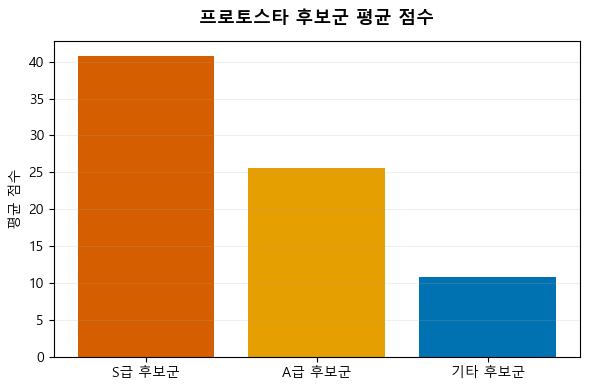

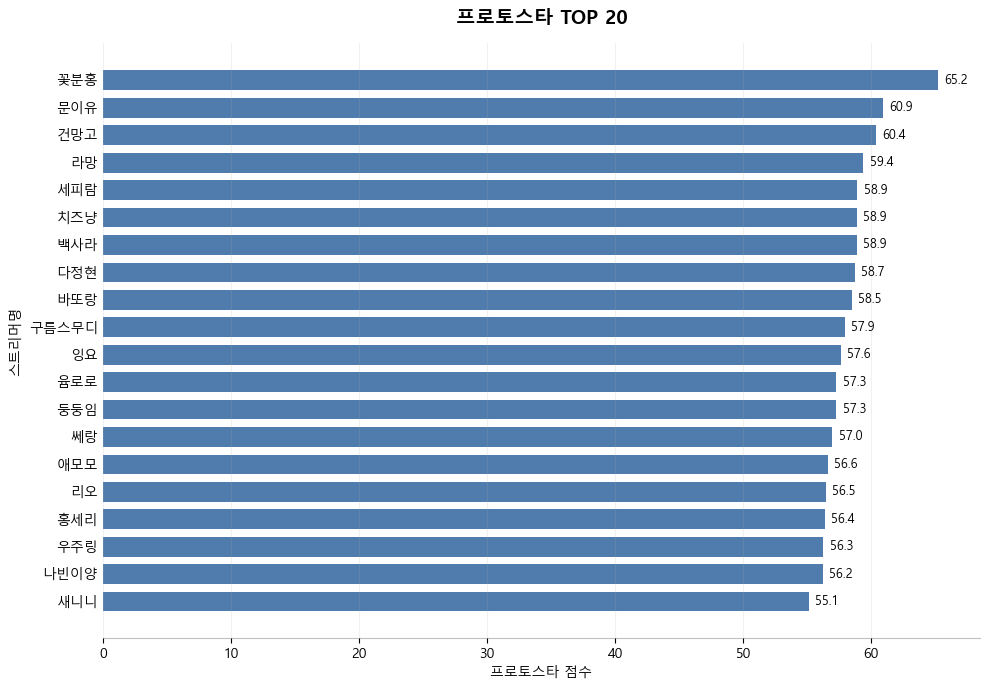

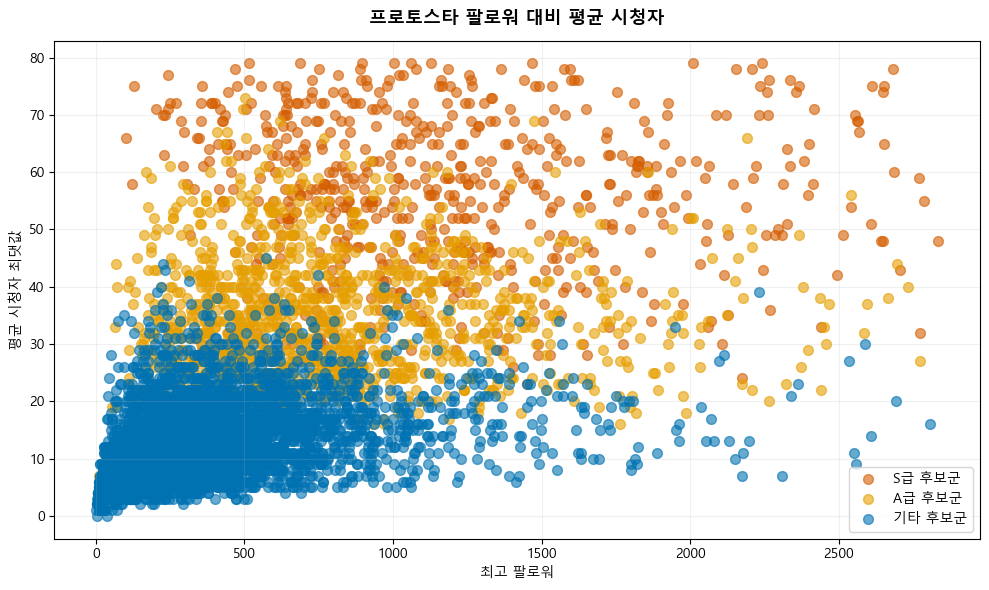

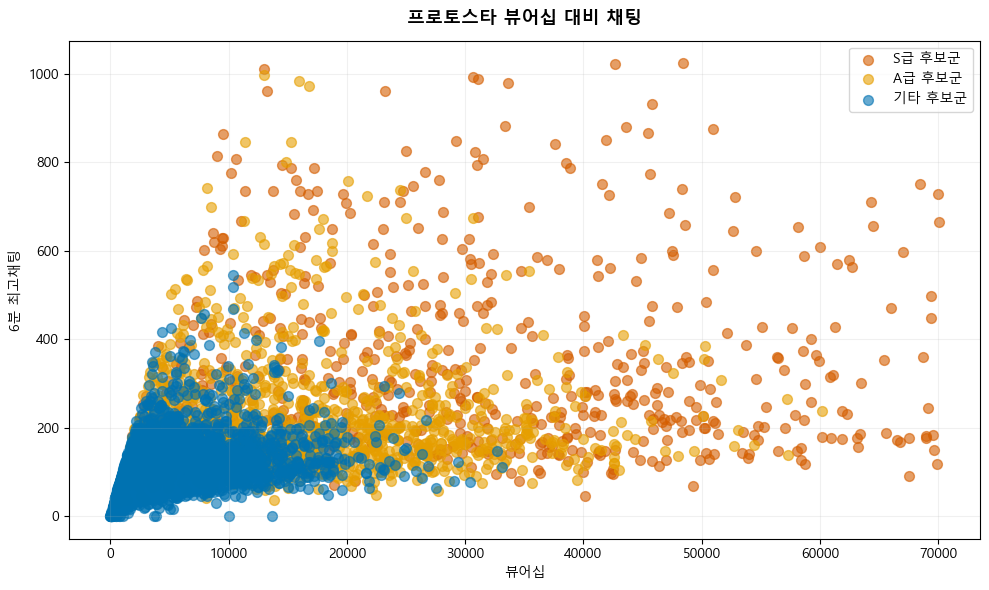

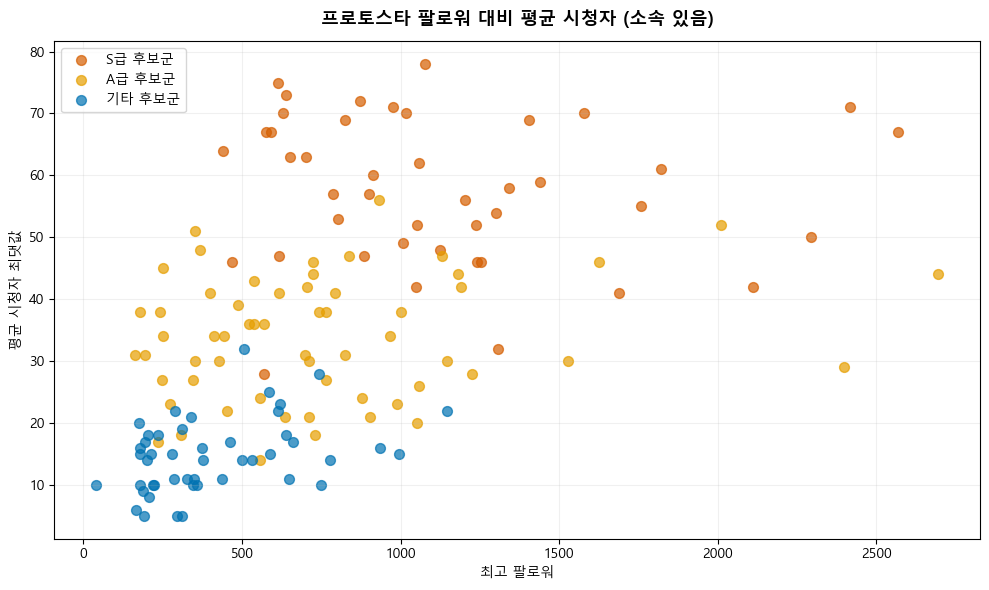

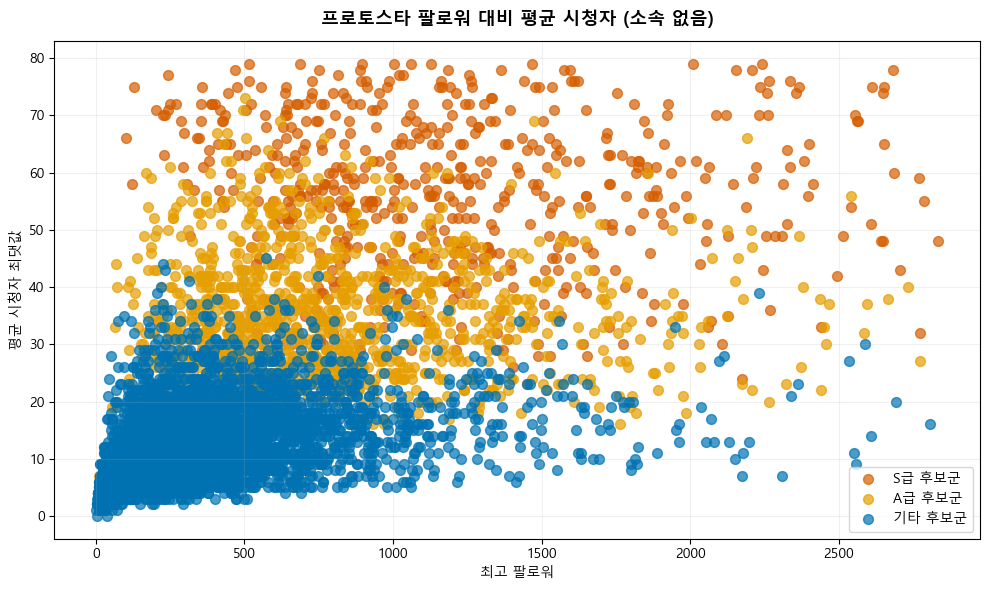

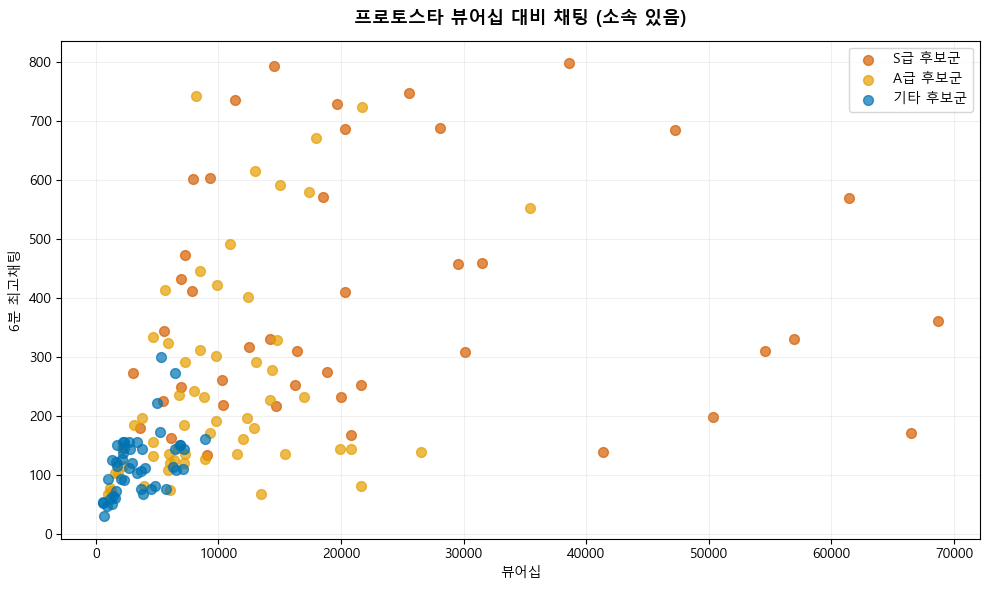

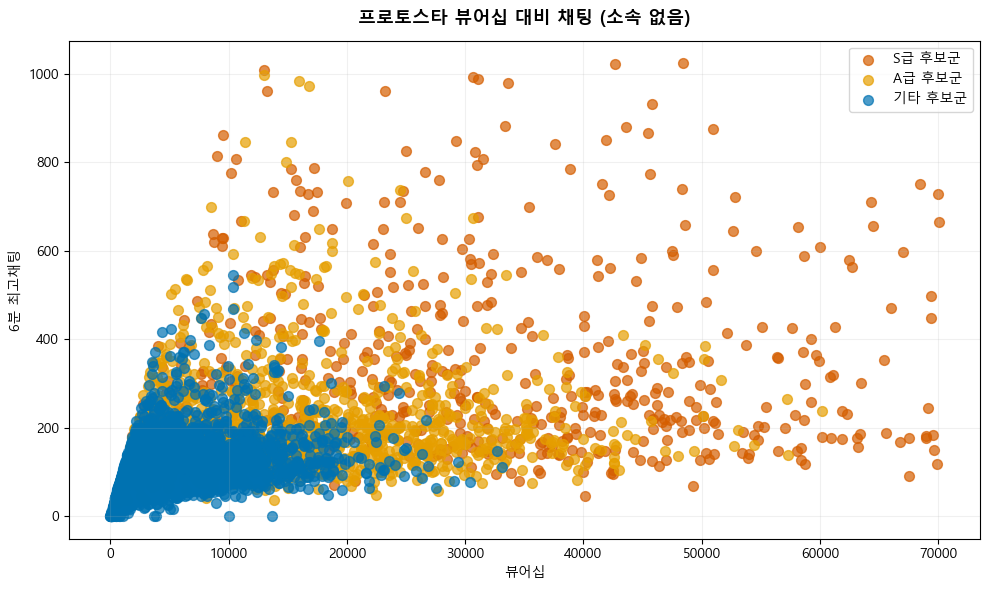

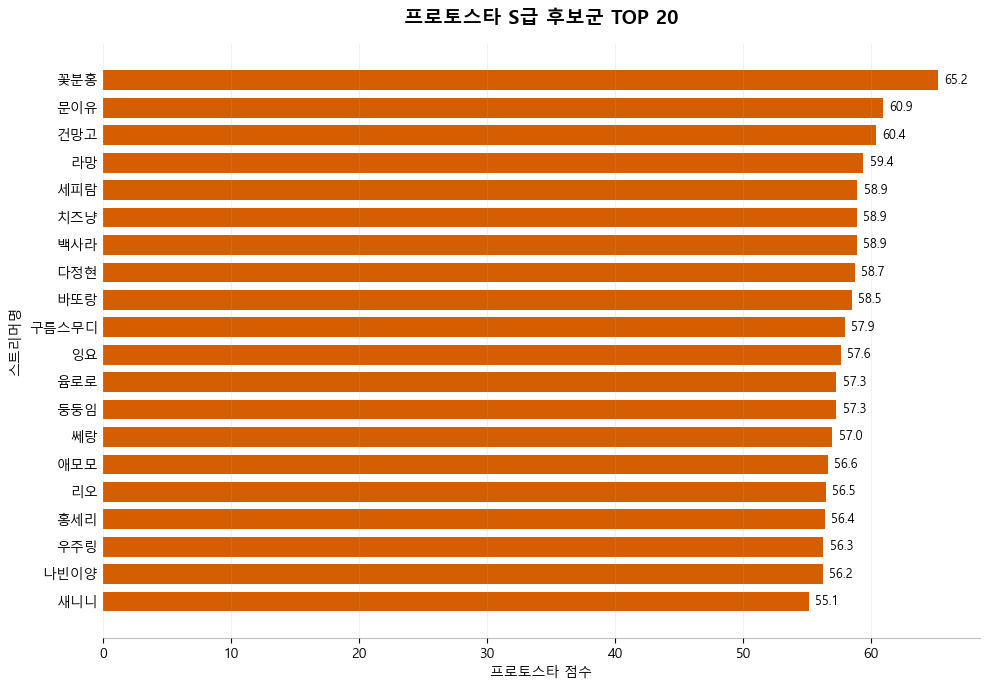

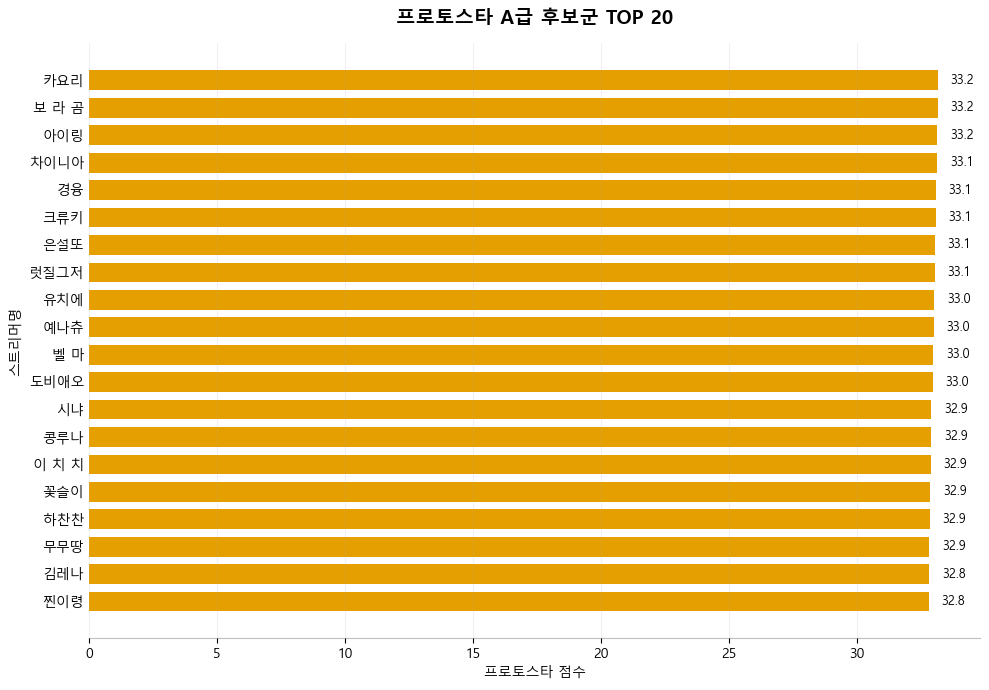

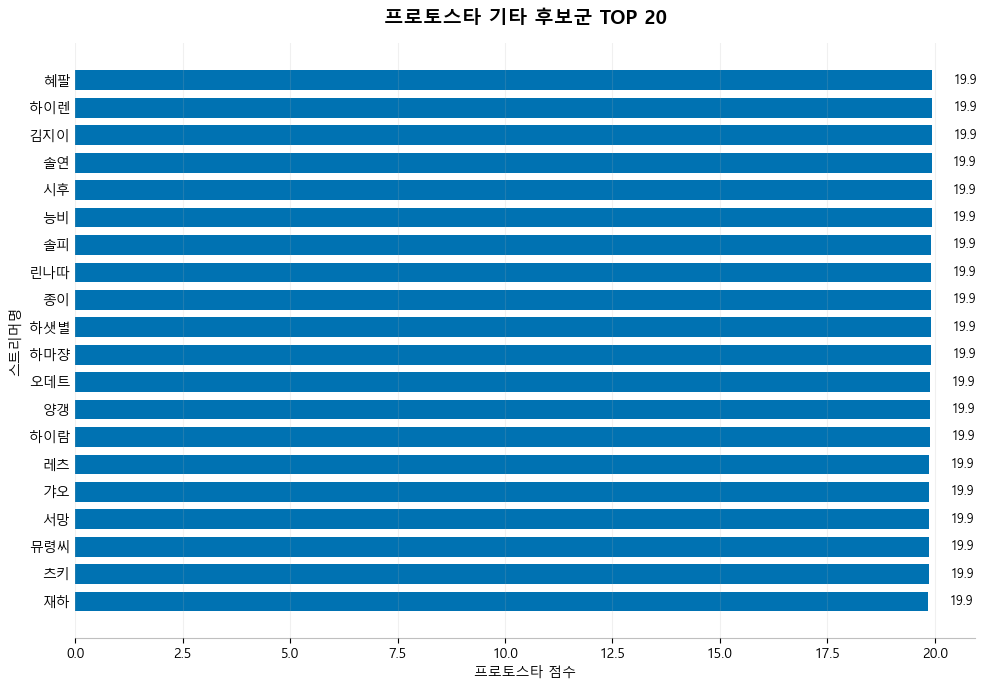

In [9]:
proto_colors = {
    "S급 후보군": "#D55E00",
    "A급 후보군": "#E69F00",
    "기타 후보군": "#0072B2",
}

proto_mean = proto_df.groupby("프로토스타_구분")["프로토스타_score"].mean().reindex(["S급 후보군", "A급 후보군", "기타 후보군"])

plt.figure(figsize=(6, 4), facecolor="white")
plt.bar(proto_mean.index, proto_mean.values, color=[proto_colors[x] for x in proto_mean.index])
plt.title("프로토스타 후보군 평균 점수", fontsize=13, fontweight="bold", pad=12)
plt.ylabel("평균 점수")
plt.grid(axis="y", alpha=0.18)
plt.tight_layout()
plt.show()

top_proto = proto_result.head(20).sort_values("프로토스타_score")
draw_horizontal_bar(
    top_proto,
    "스트리머명",
    "프로토스타_score",
    "프로토스타 TOP 20",
    color="#4F7CAC",
    xlabel="프로토스타 점수",
)

plt.figure(figsize=(10, 6), facecolor="white")
for seg in ["S급 후보군", "A급 후보군", "기타 후보군"]:
    temp = proto_df[proto_df["프로토스타_구분"] == seg]
    plt.scatter(
        temp["최고_팔로워"],
        temp["평균_시청자_최댓값"],
        label=seg,
        color=proto_colors[seg],
        alpha=0.6,
        s=50,
    )
plt.title("프로토스타 팔로워 대비 평균 시청자", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("최고 팔로워")
plt.ylabel("평균 시청자 최댓값")
plt.legend()
plt.grid(alpha=0.18)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6), facecolor="white")
for seg in ["S급 후보군", "A급 후보군", "기타 후보군"]:
    temp = proto_df[proto_df["프로토스타_구분"] == seg]
    plt.scatter(
        temp["뷰어십"],
        temp["6분_최고채팅"],
        label=seg,
        color=proto_colors[seg],
        alpha=0.6,
        s=50,
    )
plt.title("프로토스타 뷰어십 대비 채팅", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("뷰어십")
plt.ylabel("6분 최고채팅")
plt.legend()
plt.grid(alpha=0.18)
plt.tight_layout()
plt.show()

proto_true = proto_df[proto_df["소속_clean"] != ""].copy()
proto_false = proto_df[proto_df["소속_clean"] == ""].copy()

for split_name, split_df in [("소속 있음", proto_true), ("소속 없음", proto_false)]:
    plt.figure(figsize=(10, 6), facecolor="white")
    for seg in ["S급 후보군", "A급 후보군", "기타 후보군"]:
        temp = split_df[split_df["프로토스타_구분"] == seg]
        plt.scatter(
            temp["최고_팔로워"],
            temp["평균_시청자_최댓값"],
            label=seg,
            color=proto_colors[seg],
            alpha=0.7,
            s=50,
        )
    plt.title(f"프로토스타 팔로워 대비 평균 시청자 ({split_name})", fontsize=13, fontweight="bold", pad=12)
    plt.xlabel("최고 팔로워")
    plt.ylabel("평균 시청자 최댓값")
    plt.legend()
    plt.grid(alpha=0.18)
    plt.tight_layout()
    plt.show()

for split_name, split_df in [("소속 있음", proto_true), ("소속 없음", proto_false)]:
    plt.figure(figsize=(10, 6), facecolor="white")
    for seg in ["S급 후보군", "A급 후보군", "기타 후보군"]:
        temp = split_df[split_df["프로토스타_구분"] == seg]
        plt.scatter(
            temp["뷰어십"],
            temp["6분_최고채팅"],
            label=seg,
            color=proto_colors[seg],
            alpha=0.7,
            s=50,
        )
    plt.title(f"프로토스타 뷰어십 대비 채팅 ({split_name})", fontsize=13, fontweight="bold", pad=12)
    plt.xlabel("뷰어십")
    plt.ylabel("6분 최고채팅")
    plt.legend()
    plt.grid(alpha=0.18)
    plt.tight_layout()
    plt.show()

def draw_proto_top_by_tier(tier_name, color):
    tier_top = (
        proto_df[proto_df["프로토스타_구분"] == tier_name]
        .sort_values("프로토스타_score", ascending=False)
        .head(20)
        .sort_values("프로토스타_score")
    )
    draw_horizontal_bar(
        tier_top,
        "스트리머명",
        "프로토스타_score",
        f"프로토스타 {tier_name} TOP 20",
        color=color,
        xlabel="프로토스타 점수",
    )

draw_proto_top_by_tier("S급 후보군", proto_colors["S급 후보군"])
draw_proto_top_by_tier("A급 후보군", proto_colors["A급 후보군"])
draw_proto_top_by_tier("기타 후보군", proto_colors["기타 후보군"])

## 5. 위성(Satellite) 산식 정의

위성은 **도네이션, 채팅, 평균 시청자, 팬덤지수 기준으로 개인형 고화력 후보를 분류**하는 세그먼트이다.  
단, 지표가 지나치게 높거나 팔로워 체급이 큰 후보는 실제 영입 난이도를 반영해 영입제한으로 분리한다.

### 최종 산식

**위성점수 = 도네이션 30% + 6분 최고채팅 30% + 평균 시청자 30% + 팬덤지수 10%**

### 분류 기준
- **영입제한**: 초고화력 또는 팔로워 기준을 넘는 개인형 후보
- **위성(Satellite)**: 영입제한은 아니지만 상위권 실질 화력을 가진 개인형 후보
- **기타**: 위 조건에 해당하지 않는 후보

In [10]:
# =========================================================
# 위성점수 계산 + 영입제한 / 위성(Satellite) / 기타 분류
# 기존 위성점수계산.ipynb의 최종 분류 로직을 유지
# =========================================================

sat_df = df_raw.copy()

WEIGHT_DONATION = 0.30
WEIGHT_PEAK_CHAT = 0.30
WEIGHT_AVG_VIEWER = 0.30
WEIGHT_FANDOM = 0.10
NORMALIZE_WEIGHTS = True

USE_WINSORIZE = True
LOWER_Q = 0.001
UPPER_Q = 0.999
USE_LOG_FOR_FANDOM = False
FILL_NA_VALUE = 0.0

RESTRICT_DONATION_QUANTILE = 0.95
RESTRICT_PEAK_CHAT_QUANTILE = 0.95
RESTRICT_AVG_VIEWER_CUTOFF = 10000
USE_RESTRICT_SCORE_QUANTILE = False
RESTRICT_SCORE_QUANTILE = 0.90
RESTRICT_SCORE_CUTOFF = 0.865
RESTRICT_SOLO_TYPES = ["솔로확정"]

RESTRICT_FOLLOWER_CUTOFF = 40000
RESTRICT_FOLLOWER_REQUIRE_SOLO = True
RESTRICT_FOLLOWER_SOLO_TYPES = ["솔로확정", "솔로추정"]

SATELLITE_DONATION_QUANTILE = 0.85
SATELLITE_PEAK_CHAT_QUANTILE = 0.85
SATELLITE_AVG_VIEWER_CUTOFF = 1000
USE_SATELLITE_SCORE_QUANTILE = True
SATELLITE_SCORE_QUANTILE = 0.85
SATELLITE_SCORE_CUTOFF = 0.65
SATELLITE_SOLO_TYPES = ["솔로확정", "솔로추정"]

def normalize_weights(weight_dict):
    total = sum(weight_dict.values())
    if total == 0:
        raise ValueError("가중치 합이 0입니다.")
    return {k: v / total for k, v in weight_dict.items()}

def first_existing(data, candidates):
    for c in candidates:
        if c in data.columns:
            return c
    return None

col_donation = first_existing(sat_df, ["도네이션", "donation", "donation_revenue"])
col_peak_chat = first_existing(sat_df, ["6분_최고채팅", "6분최고채팅", "peak_chat_6min"])
col_avg_viewer = first_existing(sat_df, ["평균_시청자_최댓값", "평균시청자_최댓값", "avg_viewer_max"])
col_fandom = first_existing(sat_df, ["팬덤지수", "fandom_index"])
col_followers = first_existing(sat_df, ["최고_팔로워", "최고팔로워", "followers", "max_followers"])
col_affiliation = first_existing(sat_df, ["소속", "affiliation", "agency", "소속사"])

required_cols = {
    "도네이션": col_donation,
    "6분_최고채팅": col_peak_chat,
    "평균_시청자_최댓값": col_avg_viewer,
}
missing = [k for k, v in required_cols.items() if v is None]
if missing:
    raise ValueError(f"필수 컬럼이 없습니다: {missing}")

if "솔로성분류" not in sat_df.columns:
    if col_affiliation is None:
        raise ValueError("솔로성분류가 없고, 이를 생성할 소속 컬럼도 없습니다.")

    affiliation_text = sat_df[col_affiliation].astype("string").str.strip()
    sat_df["솔로성분류"] = np.where(
        affiliation_text.isna()
        | (affiliation_text == "")
        | (affiliation_text.str.lower().isin(["nan", "none", "null", "-", "없음", "무소속"])),
        "솔로확정",
        "소속확인",
    )

sat_df["도네이션_log_minmax"] = robust_minmax(
    sat_df[col_donation],
    use_log=True,
    use_winsorize=USE_WINSORIZE,
    lower_q=LOWER_Q,
    upper_q=UPPER_Q,
)
sat_df["6분_최고채팅_log_minmax"] = robust_minmax(
    sat_df[col_peak_chat],
    use_log=True,
    use_winsorize=USE_WINSORIZE,
    lower_q=LOWER_Q,
    upper_q=UPPER_Q,
)
sat_df["평균_시청자_최댓값_log_minmax"] = robust_minmax(
    sat_df[col_avg_viewer],
    use_log=True,
    use_winsorize=USE_WINSORIZE,
    lower_q=LOWER_Q,
    upper_q=UPPER_Q,
)

if col_fandom is not None:
    sat_df["팬덤지수_minmax"] = robust_minmax(
        sat_df[col_fandom],
        use_log=USE_LOG_FOR_FANDOM,
        use_winsorize=USE_WINSORIZE,
        lower_q=LOWER_Q,
        upper_q=UPPER_Q,
    )
else:
    sat_df["팬덤지수_minmax"] = 0.5

weights = {
    "donation": WEIGHT_DONATION,
    "peak_chat": WEIGHT_PEAK_CHAT,
    "avg_viewer": WEIGHT_AVG_VIEWER,
    "fandom": WEIGHT_FANDOM,
}
if NORMALIZE_WEIGHTS:
    weights = normalize_weights(weights)

sat_df["위성점수_log_minmax_raw"] = (
    sat_df["도네이션_log_minmax"] * weights["donation"]
    + sat_df["6분_최고채팅_log_minmax"] * weights["peak_chat"]
    + sat_df["평균_시청자_최댓값_log_minmax"] * weights["avg_viewer"]
    + sat_df["팬덤지수_minmax"] * weights["fandom"]
)

if "솔로성보정계수" in sat_df.columns:
    sat_df["솔로성보정계수"] = pd.to_numeric(sat_df["솔로성보정계수"], errors="coerce").fillna(1)
    sat_df["위성점수_log_minmax"] = sat_df["위성점수_log_minmax_raw"] * sat_df["솔로성보정계수"]
else:
    sat_df["위성점수_log_minmax"] = sat_df["위성점수_log_minmax_raw"]

sat_df[col_donation] = pd.to_numeric(sat_df[col_donation], errors="coerce")
sat_df[col_peak_chat] = pd.to_numeric(sat_df[col_peak_chat], errors="coerce")
sat_df[col_avg_viewer] = pd.to_numeric(sat_df[col_avg_viewer], errors="coerce")
if col_followers is not None:
    sat_df[col_followers] = pd.to_numeric(sat_df[col_followers], errors="coerce")

restrict_donation_cutoff = sat_df[col_donation].quantile(RESTRICT_DONATION_QUANTILE)
restrict_peak_chat_cutoff = sat_df[col_peak_chat].quantile(RESTRICT_PEAK_CHAT_QUANTILE)
restrict_avg_viewer_cutoff = RESTRICT_AVG_VIEWER_CUTOFF
satellite_donation_cutoff = sat_df[col_donation].quantile(SATELLITE_DONATION_QUANTILE)
satellite_peak_chat_cutoff = sat_df[col_peak_chat].quantile(SATELLITE_PEAK_CHAT_QUANTILE)
satellite_avg_viewer_cutoff = SATELLITE_AVG_VIEWER_CUTOFF

if USE_RESTRICT_SCORE_QUANTILE:
    restrict_score_cutoff = sat_df["위성점수_log_minmax"].quantile(RESTRICT_SCORE_QUANTILE)
else:
    restrict_score_cutoff = RESTRICT_SCORE_CUTOFF

if USE_SATELLITE_SCORE_QUANTILE:
    satellite_score_cutoff = sat_df["위성점수_log_minmax"].quantile(SATELLITE_SCORE_QUANTILE)
else:
    satellite_score_cutoff = SATELLITE_SCORE_CUTOFF

print("\n" + "=" * 80)
print("[영입제한 / 위성(Satellite) 분류 기준]")
print("=" * 80)
print(f"영입제한 도네이션 기준: {restrict_donation_cutoff:,.0f}")
print(f"영입제한 6분 최고채팅 기준: {restrict_peak_chat_cutoff:,.0f}")
print(f"영입제한 평균 시청자 기준: {restrict_avg_viewer_cutoff:,.0f}")
print(f"영입제한 위성점수 기준: {restrict_score_cutoff:.4f}")
print(f"영입제한 최고 팔로워 기준: {RESTRICT_FOLLOWER_CUTOFF:,.0f}")
print("-" * 80)
print(f"위성 도네이션 기준: {satellite_donation_cutoff:,.0f}")
print(f"위성 6분 최고채팅 기준: {satellite_peak_chat_cutoff:,.0f}")
print(f"위성 평균 시청자 기준: {satellite_avg_viewer_cutoff:,.0f}")
print(f"위성점수 기준: {satellite_score_cutoff:.4f}")

sat_df["조건_영입제한_솔로성충족"] = sat_df["솔로성분류"].isin(RESTRICT_FOLLOWER_SOLO_TYPES)
sat_df["조건_영입제한_도네이션충족"] = sat_df[col_donation] >= restrict_donation_cutoff
sat_df["조건_영입제한_채팅충족"] = sat_df[col_peak_chat] >= restrict_peak_chat_cutoff
sat_df["조건_영입제한_평균시청자충족"] = sat_df[col_avg_viewer] >= restrict_avg_viewer_cutoff
sat_df["조건_영입제한_점수충족"] = sat_df["위성점수_log_minmax"] >= restrict_score_cutoff

if col_followers is not None:
    sat_df["조건_영입제한_팔로워충족"] = sat_df[col_followers] >= RESTRICT_FOLLOWER_CUTOFF
else:
    sat_df["조건_영입제한_팔로워충족"] = False

sat_df["조건_영입제한_지표기반"] = (
    sat_df["조건_영입제한_솔로성충족"]
    & sat_df["조건_영입제한_도네이션충족"]
    & sat_df["조건_영입제한_채팅충족"]
    & sat_df["조건_영입제한_평균시청자충족"]
    & sat_df["조건_영입제한_점수충족"]
)
sat_df["조건_영입제한_점수기반"] = (
    sat_df["조건_영입제한_솔로성충족"]
    & sat_df["조건_영입제한_점수충족"]
)

if RESTRICT_FOLLOWER_REQUIRE_SOLO:
    sat_df["조건_영입제한_팔로워기반"] = (
        sat_df["조건_영입제한_솔로성충족"]
        & sat_df["조건_영입제한_팔로워충족"]
    )
else:
    sat_df["조건_영입제한_팔로워기반"] = sat_df["조건_영입제한_팔로워충족"]

sat_df["조건_위성_솔로성충족"] = sat_df["솔로성분류"].isin(SATELLITE_SOLO_TYPES)
sat_df["조건_위성_도네이션충족"] = sat_df[col_donation] >= satellite_donation_cutoff
sat_df["조건_위성_채팅충족"] = sat_df[col_peak_chat] >= satellite_peak_chat_cutoff
sat_df["조건_위성_평균시청자충족"] = sat_df[col_avg_viewer] >= satellite_avg_viewer_cutoff
sat_df["조건_위성_점수충족"] = sat_df["위성점수_log_minmax"] >= satellite_score_cutoff

sat_df["영입제한여부"] = (
    sat_df["조건_영입제한_지표기반"]
    | sat_df["조건_영입제한_점수기반"]
    | sat_df["조건_영입제한_팔로워기반"]
)
sat_df["위성여부"] = (
    ~sat_df["영입제한여부"]
    & sat_df["조건_위성_솔로성충족"]
    & sat_df["조건_위성_도네이션충족"]
    & sat_df["조건_위성_채팅충족"]
    & sat_df["조건_위성_평균시청자충족"]
    & sat_df["조건_위성_점수충족"]
)

def assign_satellite_segment(row):
    if row["영입제한여부"]:
        return "영입제한"
    if row["위성여부"]:
        return "위성(Satellite)"
    return "기타"

sat_df["세그먼트_위성"] = sat_df.apply(assign_satellite_segment, axis=1)
sat_df["위성점수"] = (sat_df["위성점수_log_minmax"].clip(0, 1) * 100).round(2)

sat_drop_cols = [
    "도네이션_log_minmax", "6분_최고채팅_log_minmax", "평균_시청자_최댓값_log_minmax",
    "팬덤지수_minmax", "위성점수_log_minmax_raw", "위성점수_log_minmax",
    "솔로성분류", "조건_영입제한_솔로성충족", "조건_영입제한_도네이션충족",
    "조건_영입제한_채팅충족", "조건_영입제한_평균시청자충족", "조건_영입제한_점수충족",
    "조건_영입제한_지표기반", "조건_영입제한_점수기반", "조건_영입제한_팔로워충족",
    "조건_영입제한_팔로워기반", "조건_위성_솔로성충족", "조건_위성_도네이션충족",
    "조건_위성_채팅충족", "조건_위성_평균시청자충족", "조건_위성_점수충족",
    "영입제한여부", "위성여부",
]
sat_df = sat_df.drop(columns=[c for c in sat_drop_cols if c in sat_df.columns])

sat_result = sat_df.sort_values("위성점수", ascending=False).reset_index(drop=True)
satellite_final_output = sat_df[sat_df["세그먼트_위성"] == "위성(Satellite)"].sort_values(by="위성점수", ascending=False)

display(sat_result["세그먼트_위성"].value_counts().rename_axis("구분").reset_index(name="인원수"))
display(satellite_final_output.head(5))


[영입제한 / 위성(Satellite) 분류 기준]
영입제한 도네이션 기준: 1,144,725
영입제한 6분 최고채팅 기준: 1,335
영입제한 평균 시청자 기준: 10,000
영입제한 위성점수 기준: 0.8650
영입제한 최고 팔로워 기준: 40,000
--------------------------------------------------------------------------------
위성 도네이션 기준: 462,141
위성 6분 최고채팅 기준: 404
위성 평균 시청자 기준: 1,000
위성점수 기준: 0.5853


,구분,인원수
0,기타,10975
1,위성(Satellite),115
2,영입제한,67


,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,소속,세그먼트_위성,위성점수
263,고여름,SOOP,gosummer,2025.01.01 ~ 2026.03.31,28244,2094,14206,7148,13617,7344,294293,781041,-4.8,-25.9,0,17200,1725,NaN,위성(Satellite),85.53
149,유시에,SOOP,sie4yu,2025.01.01 ~ 2026.03.31,16192,4044,7728,1211,12194,7189,647458,2578034,-30.2,-39.3,0,865,310,NaN,위성(Satellite),85.40
25,독케익,CHZZK,b68af124ae2f1743a1dcbf5e2ab41e0b,2025.01.01 ~ 2026.03.31,36004,3442,6659,1880,6748,3321,3998165,4905395,-6.3,-8.9,0,18500,12258,NaN,위성(Satellite),84.89
111,남궁혁,CHZZK,2cc562e9370970d567c1a25c5c7d0e77,2025.01.01 ~ 2026.03.31,34916,1102,3608,2436,17962,9705,926140,2085715,7.4,-8.9,0,75700,11927,NaN,위성(Satellite),84.66
79,엘시,CHZZK,6ccaebc2569f62344c6fc257f8f2b9ad,2025.07.18 ~ 2026.03.31,31686,1265,3303,921,12134,9420,1425457,2240704,8.1,-14.2,0,73100,6342,NaN,위성(Satellite),84.25


### 위성 시각화

위성 및 영입제한 후보 상위권을 확인한다.

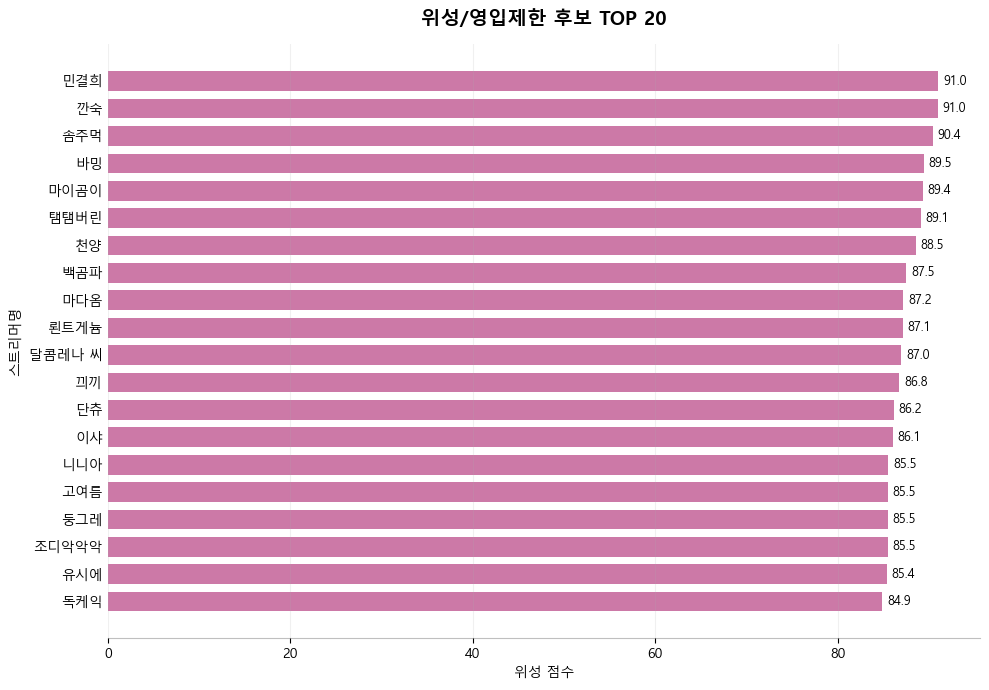

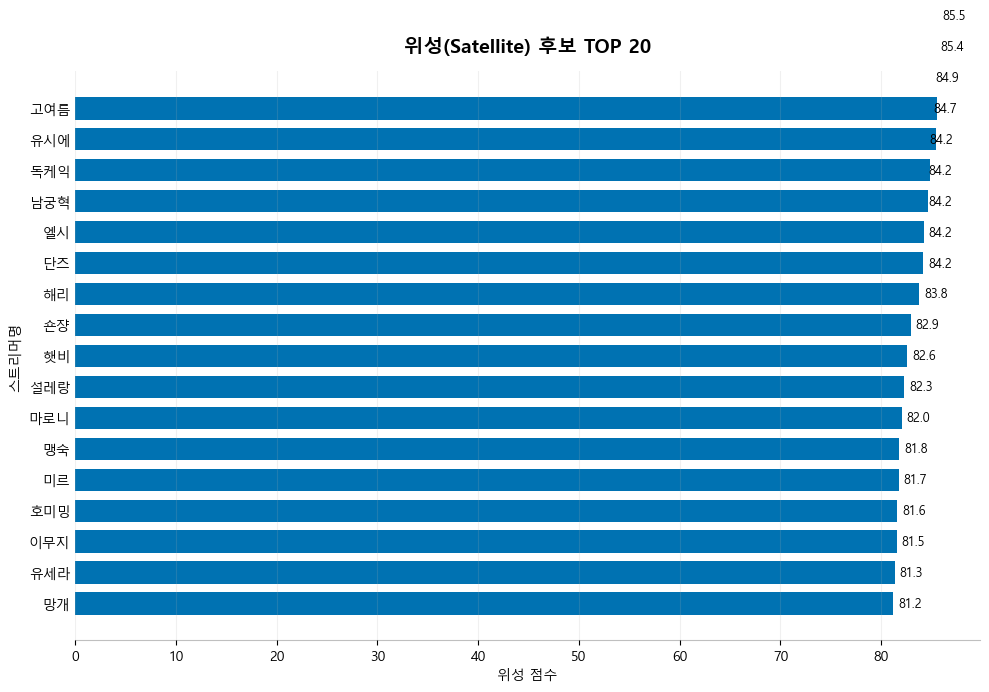

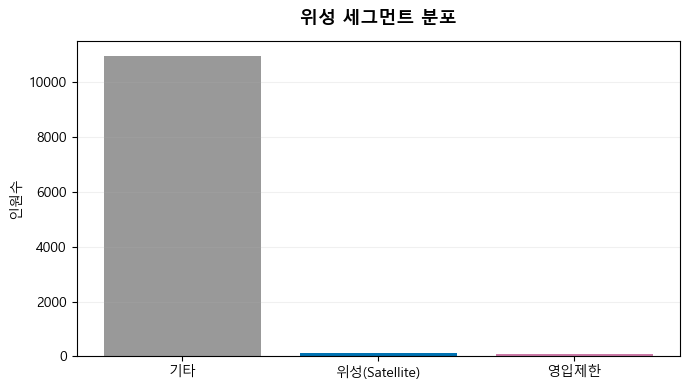

In [11]:
satellite_candidates = sat_result[sat_result["세그먼트_위성"].isin(["위성(Satellite)", "영입제한"])].head(20)
draw_horizontal_bar(
    satellite_candidates,
    "스트리머명",
    "위성점수",
    "위성/영입제한 후보 TOP 20",
    color="#CC79A7",
    xlabel="위성 점수",
)

satellite_only_top20 = satellite_final_output.head(20)
draw_horizontal_bar(
    satellite_only_top20,
    "스트리머명",
    "위성점수",
    "위성(Satellite) 후보 TOP 20",
    color="#0072B2",
    xlabel="위성 점수",
)

sat_counts = sat_result["세그먼트_위성"].value_counts()
plt.figure(figsize=(7, 4), facecolor="white")
plt.bar(sat_counts.index, sat_counts.values, color=["#999999", "#0072B2", "#CC79A7"][:len(sat_counts)])
plt.title("위성 세그먼트 분포", fontsize=13, fontweight="bold", pad=12)
plt.ylabel("인원수")
plt.grid(axis="y", alpha=0.18)
plt.tight_layout()
plt.show()

## 6. 슈퍼노바(Supernova) 산식 정의

슈퍼노바는 단순히 방송 성과만 높은 후보가 아니라, **외부 유입 가능성, 팬덤 규모, 실질 방송 화력**을 함께 갖춘 최상위 후보군을 찾는 세그먼트이다.

### 최종 산식

**최종 슈퍼노바 점수 = 대중성 50% + 팬덤체급 25% + 방송화력 25%**

### 후보군 기준
- **65점 이상**: 슈퍼노바 핵심 후보군
- **60점 이상 65점 미만**: 전략 검토 후보군
- **60점 미만**: 일반 후보군

In [12]:
supernova_df = df_raw.copy()

supernova_score_cols = [
    "최고_팔로워", "최고_시청자", "유튜브_유입지수", "도네이션",
    "6분_최고채팅", "평균_시청자_최댓값", "팬덤지수", "뷰어십", "유튜브_구독자"
]
supernova_df = ensure_numeric(supernova_df, supernova_score_cols)

supernova_log_cols = [
    "최고_팔로워", "최고_시청자", "도네이션", "6분_최고채팅",
    "평균_시청자_최댓값", "뷰어십", "유튜브_구독자"
]

for col in supernova_log_cols:
    supernova_df[f"log_{col}"] = np.log1p(supernova_df[col].clip(lower=0))

supernova_scale_map = {
    "팔로워_score": "log_최고_팔로워",
    "최고시청자_score": "log_최고_시청자",
    "유튜브유입_score": "유튜브_유입지수",
    "도네이션_score": "log_도네이션",
    "채팅화력_score": "log_6분_최고채팅",
    "평균시청자_score": "log_평균_시청자_최댓값",
    "팬덤지수_score": "팬덤지수",
    "뷰어십_score": "log_뷰어십",
    "유튜브구독자_score": "log_유튜브_구독자",
}

for score_col, source_col in supernova_scale_map.items():
    supernova_df[score_col] = safe_minmax(supernova_df[source_col])

supernova_df["대중성_score"] = (
    supernova_df["유튜브유입_score"] * 0.50
    + supernova_df["최고시청자_score"] * 0.30
    + supernova_df["팔로워_score"] * 0.20
)

supernova_df["팬덤체급_score"] = (
    supernova_df["유튜브구독자_score"] * 0.40
    + supernova_df["뷰어십_score"] * 0.40
    + supernova_df["팬덤지수_score"] * 0.20
)

supernova_df["방송화력_score"] = (
    supernova_df["도네이션_score"] * 0.40
    + supernova_df["채팅화력_score"] * 0.30
    + supernova_df["평균시청자_score"] * 0.30
)

supernova_df["슈퍼노바_score"] = (
    supernova_df["대중성_score"] * 0.50
    + supernova_df["팬덤체급_score"] * 0.25
    + supernova_df["방송화력_score"] * 0.25
)

SUPERNOVA_CORE_CUTOFF = 65
SUPERNOVA_REVIEW_CUTOFF = 60

def supernova_tier(score):
    if score >= SUPERNOVA_CORE_CUTOFF:
        return "슈퍼노바 핵심 후보군"
    if score >= SUPERNOVA_REVIEW_CUTOFF:
        return "전략 검토 후보군"
    return "일반 후보군"

supernova_df["슈퍼노바_구분"] = supernova_df["슈퍼노바_score"].apply(supernova_tier)

supernova_result_cols = [
    "스트리머명", "플랫폼", "소속", "최고_팔로워", "최고_시청자",
    "도네이션", "6분_최고채팅", "평균_시청자_최댓값", "유튜브_유입지수",
    "유튜브_구독자", "팬덤지수", "뷰어십", "대중성_score",
    "팬덤체급_score", "방송화력_score", "슈퍼노바_score", "슈퍼노바_구분"
]

supernova_result = (
    supernova_df[supernova_result_cols]
    .sort_values("슈퍼노바_score", ascending=False)
    .reset_index(drop=True)
)

supernova_summary = supernova_result["슈퍼노바_구분"].value_counts().rename_axis("구분").reset_index(name="인원수")
display(supernova_summary)
supernova_result.head(20)

,구분,인원수
0,일반 후보군,11057
1,전략 검토 후보군,77
2,슈퍼노바 핵심 후보군,23


,스트리머명,플랫폼,소속,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,유튜브_구독자,팬덤지수,뷰어십,대중성_score,팬덤체급_score,방송화력_score,슈퍼노바_score,슈퍼노바_구분
0,고세구,SOOP,이세계아이돌,199696,39102,5905590,95063,23877,8.2,545000,9.8,10855404,54.253498,79.165856,98.459542,71.533099,슈퍼노바 핵심 후보군
1,시라유키 히나,CHZZK,스텔라이브,219675,47218,6864206,6960,30958,2.6,302000,4.4,8608945,54.620978,76.791456,92.830024,69.715859,슈퍼노바 핵심 후보군
2,주르르,SOOP,이세계아이돌,175519,27415,3250999,55406,17295,7.2,417000,11.0,4794346,53.009609,76.514593,94.612701,69.286628,슈퍼노바 핵심 후보군
3,비챤,SOOP,이세계아이돌,176315,20891,2862540,108416,16694,5.2,331000,10.9,5657369,52.149919,76.276027,95.924277,69.125035,슈퍼노바 핵심 후보군
4,아카네 리제,CHZZK,스텔라이브,235506,40960,6069644,5873,23109,2.5,319000,3.9,5983879,54.326821,76.049127,91.230281,68.983262,슈퍼노바 핵심 후보군
5,탬탬버린,CHZZK,NaN,308659,23115,6876167,5923,13532,4.4,537000,-13.9,17075004,53.254149,79.331147,90.016164,68.963902,슈퍼노바 핵심 후보군
6,릴파,SOOP,이세계아이돌,185167,21790,5796867,13983,18865,7.0,434000,10.5,7788723,52.441361,77.770914,92.769388,68.855756,슈퍼노바 핵심 후보군
7,텐코 시부키,CHZZK,스텔라이브,222276,34645,6737178,7255,16465,-0.7,204000,4.1,14216251,53.596017,76.910885,91.058295,68.790304,슈퍼노바 핵심 후보군
8,유즈하 리코,CHZZK,스텔라이브,183957,36983,6609127,7092,21539,0.0,183000,5.6,6673506,53.523651,74.852816,91.730136,68.407563,슈퍼노바 핵심 후보군
9,아야츠노 유니,CHZZK,스텔라이브,281741,21414,6715398,6674,14086,1.7,347000,2.8,10770780,52.752609,77.650340,90.381397,68.384239,슈퍼노바 핵심 후보군


### 슈퍼노바 시각화

핵심 후보군 TOP 20과 세부 점수별 기여 구조를 확인한다.

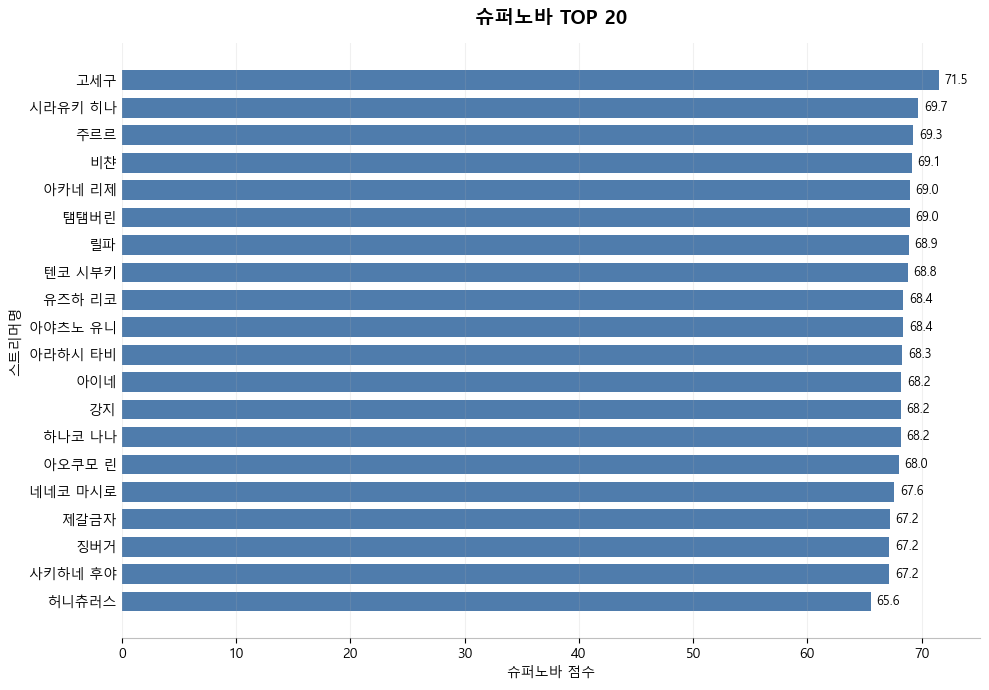

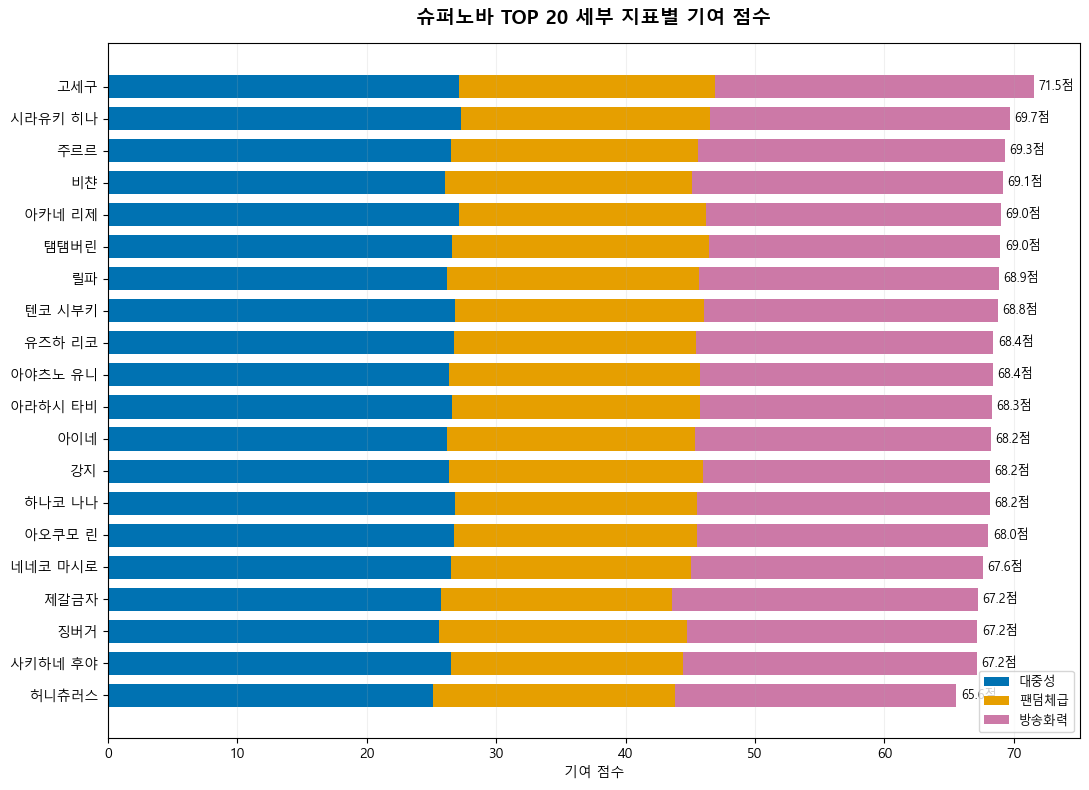

In [13]:
supernova_top20 = supernova_result.head(20).copy()

draw_horizontal_bar(
    supernova_top20,
    "스트리머명",
    "슈퍼노바_score",
    "슈퍼노바 TOP 20",
    color="#4F7CAC",
    xlabel="슈퍼노바 점수",
)

supernova_top20["대중성_기여점수"] = supernova_top20["대중성_score"] * 0.50
supernova_top20["팬덤체급_기여점수"] = supernova_top20["팬덤체급_score"] * 0.25
supernova_top20["방송화력_기여점수"] = supernova_top20["방송화력_score"] * 0.25

plot_df = supernova_top20.sort_values("슈퍼노바_score", ascending=True)
left = np.zeros(len(plot_df))
contribution_cols = ["대중성_기여점수", "팬덤체급_기여점수", "방송화력_기여점수"]
contribution_labels = ["대중성", "팬덤체급", "방송화력"]
contribution_colors = ["#0072B2", "#E69F00", "#CC79A7"]

plt.figure(figsize=(11, 8), facecolor="white")
for col, label, color in zip(contribution_cols, contribution_labels, contribution_colors):
    plt.barh(plot_df["스트리머명"], plot_df[col], left=left, label=label, color=color, height=0.72)
    left += plot_df[col].values

for i, score in enumerate(plot_df["슈퍼노바_score"]):
    plt.text(score + 0.35, i, f"{score:.1f}점", va="center", fontsize=9)

plt.title("슈퍼노바 TOP 20 세부 지표별 기여 점수", fontsize=14, fontweight="bold", pad=14)
plt.xlabel("기여 점수")
plt.legend(loc="lower right", frameon=True, fontsize=9)
plt.grid(axis="x", alpha=0.18)
plt.tight_layout()
plt.show()

### 슈퍼노바 EDA 근거

세부 점수와 최종 점수 간 상관관계, 원본 지표 간 관계를 확인한다.

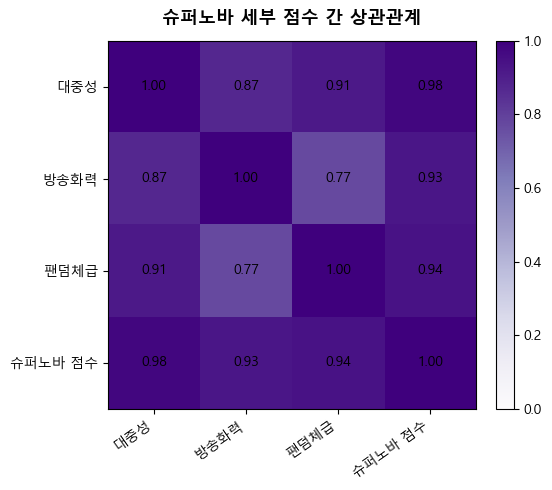

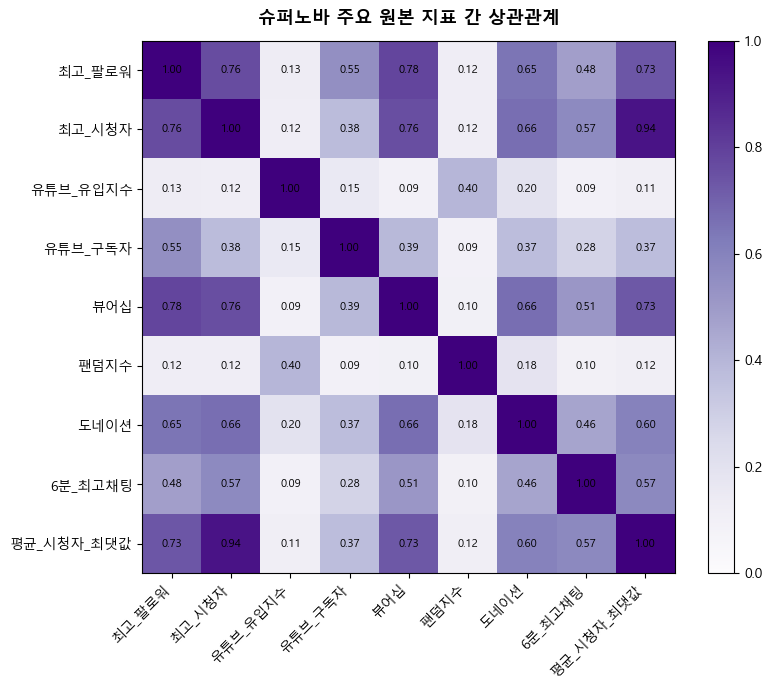

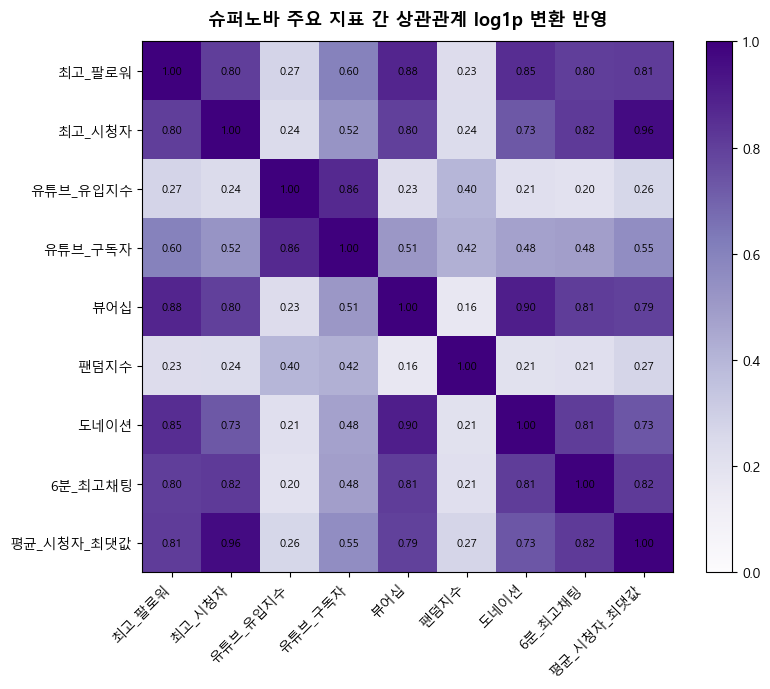

,표시그룹,대표스트리머,소속_표시,대표점수,후보수
0,이세계아이돌,고세구,이세계아이돌,71.5,6
1,스텔라이브,시라유키 히나,스텔라이브,69.7,11
2,탬탬버린,탬탬버린,무소속,69.0,1
3,블루점프,제갈금자,블루점프,67.2,1
4,프로젝트아이,허니츄러스,프로젝트아이,65.6,2
5,천양,천양,무소속,65.4,1
6,에스더,아리사,에스더,65.3,3
7,민결희,민결희,무소속,65.1,1
8,마이곰이,마이곰이,무소속,64.9,1
9,유소나,유소나,무소속,64.7,1


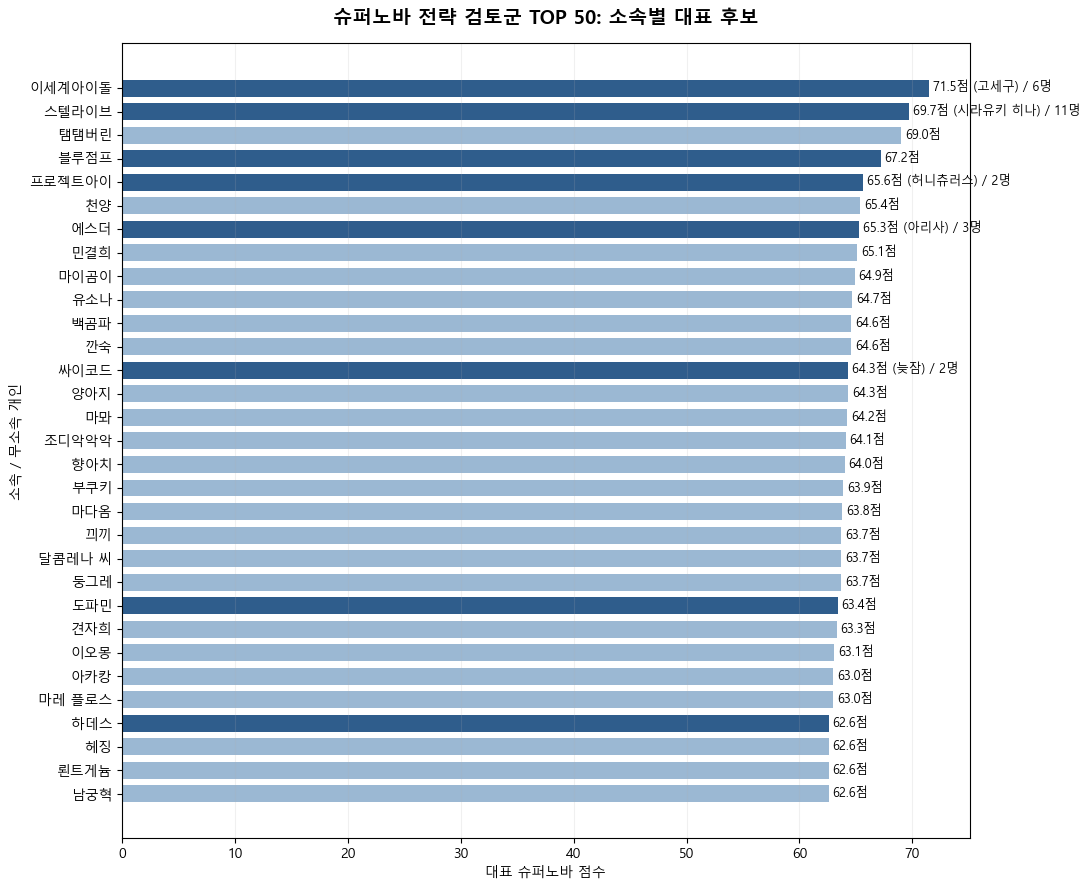

,대중성_score,방송화력_score,팬덤체급_score,슈퍼노바_score
대중성_score,1.000000,0.871480,0.914533,0.980043
방송화력_score,0.871480,1.000000,0.771067,0.927518
팬덤체급_score,0.914533,0.771067,1.000000,0.940805
슈퍼노바_score,0.980043,0.927518,0.940805,1.000000


In [14]:
score_corr_cols = ["대중성_score", "방송화력_score", "팬덤체급_score", "슈퍼노바_score"]
score_corr = supernova_result[score_corr_cols].corr()

plt.figure(figsize=(6, 5), facecolor="white")
im = plt.imshow(score_corr, cmap="Purples", vmin=0, vmax=1)
axis_labels = ["대중성", "방송화력", "팬덤체급", "슈퍼노바 점수"]
plt.xticks(range(len(score_corr_cols)), axis_labels, rotation=35, ha="right")
plt.yticks(range(len(score_corr_cols)), axis_labels)
for i in range(len(score_corr_cols)):
    for j in range(len(score_corr_cols)):
        plt.text(j, i, f"{score_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)
plt.title("슈퍼노바 세부 점수 간 상관관계", fontsize=13, fontweight="bold", pad=12)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

raw_corr_cols = [
    "최고_팔로워", "최고_시청자", "유튜브_유입지수", "유튜브_구독자",
    "뷰어십", "팬덤지수", "도네이션", "6분_최고채팅", "평균_시청자_최댓값"
]
raw_corr = supernova_df[raw_corr_cols].corr()

plt.figure(figsize=(9, 7), facecolor="white")
im = plt.imshow(raw_corr, cmap="Purples", vmin=0, vmax=1)
plt.xticks(range(len(raw_corr_cols)), raw_corr_cols, rotation=45, ha="right")
plt.yticks(range(len(raw_corr_cols)), raw_corr_cols)
for i in range(len(raw_corr_cols)):
    for j in range(len(raw_corr_cols)):
        plt.text(j, i, f"{raw_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("슈퍼노바 주요 원본 지표 간 상관관계", fontsize=13, fontweight="bold", pad=12)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

log_corr_df = supernova_df[raw_corr_cols].copy()
for col in ["최고_팔로워", "최고_시청자", "유튜브_구독자", "뷰어십", "도네이션", "6분_최고채팅", "평균_시청자_최댓값"]:
    log_corr_df[col] = np.log1p(log_corr_df[col].clip(lower=0))
log_corr = log_corr_df.corr()

plt.figure(figsize=(9, 7), facecolor="white")
im = plt.imshow(log_corr, cmap="Purples", vmin=0, vmax=1)
plt.xticks(range(len(raw_corr_cols)), raw_corr_cols, rotation=45, ha="right")
plt.yticks(range(len(raw_corr_cols)), raw_corr_cols)
for i in range(len(raw_corr_cols)):
    for j in range(len(raw_corr_cols)):
        plt.text(j, i, f"{log_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("슈퍼노바 주요 지표 간 상관관계 log1p 변환 반영", fontsize=13, fontweight="bold", pad=12)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

strategy_top50 = (
    supernova_result[supernova_result["슈퍼노바_score"] >= SUPERNOVA_REVIEW_CUTOFF]
    .sort_values("슈퍼노바_score", ascending=False)
    .head(50)
    .copy()
)
strategy_top50["소속_표시"] = strategy_top50["소속"].apply(clean_affiliation).replace("", "무소속")
strategy_top50["표시그룹"] = strategy_top50.apply(
    lambda row: row["스트리머명"] if row["소속_표시"] == "무소속" else row["소속_표시"],
    axis=1,
)

group_count = strategy_top50.groupby("표시그룹").size().reset_index(name="후보수")
group_rep = (
    strategy_top50
    .sort_values("슈퍼노바_score", ascending=False)
    .groupby("표시그룹", as_index=False)
    .first()[["표시그룹", "스트리머명", "소속_표시", "슈퍼노바_score"]]
    .rename(columns={"스트리머명": "대표스트리머", "슈퍼노바_score": "대표점수"})
)
supernova_group_result = (
    group_rep
    .merge(group_count, on="표시그룹", how="left")
    .sort_values("대표점수", ascending=False)
    .reset_index(drop=True)
)
supernova_group_result["대표점수"] = supernova_group_result["대표점수"].round(1)
display(supernova_group_result)

plot_df = supernova_group_result.sort_values("대표점수", ascending=True).copy()
colors = ["#9BB8D3" if x == "무소속" else "#2F5D8C" for x in plot_df["소속_표시"]]
plt.figure(figsize=(11, 9), facecolor="white")
plt.barh(plot_df["표시그룹"], plot_df["대표점수"], color=colors, height=0.72)
for i, row in enumerate(plot_df.itertuples()):
    label = f"{row.대표점수:.1f}점 ({row.대표스트리머}) / {row.후보수}명" if row.후보수 > 1 else f"{row.대표점수:.1f}점"
    plt.text(row.대표점수 + 0.35, i, label, va="center", fontsize=9)
plt.title("슈퍼노바 전략 검토군 TOP 50: 소속별 대표 후보", fontsize=14, fontweight="bold", pad=14)
plt.xlabel("대표 슈퍼노바 점수")
plt.ylabel("소속 / 무소속 개인")
plt.grid(axis="x", alpha=0.18)
plt.tight_layout()
plt.show()

score_corr

## 7. 코멧(Comet) 산식 정의

코멧은 방송 플랫폼 안에서는 아직 중소 체급으로 보이지만, **X 또는 유튜브 등 외부 플랫폼에 팬덤이 있어 유입 전환 가능성이 높은 후보군**을 찾는 세그먼트이다.

### 후보군 조건
- **조건 1**: X 팔로워 TOP 200 또는 유튜브 구독자 TOP 200
- **조건 2**: X 유입지수 TOP 200 또는 유튜브 유입지수 TOP 200

### 최종 점수

**코멧 raw score = log1p(X 팔로워 + 유튜브 구독자) / log1p(최고 팔로워)**

코멧 후보군 내부에서만 0~100점으로 정규화한다.

In [15]:
comet_df = df_raw.copy()

comet_drop_cols = ["코멧여부", "코멧score", "코멧유입경로", "_코멧_raw_score"]
comet_df = comet_df.drop(columns=[col for col in comet_drop_cols if col in comet_df.columns])

comet_num_cols = ["X_팔로워", "유튜브_구독자", "최고_팔로워", "유튜브_유입지수"]
comet_df = ensure_numeric(comet_df, comet_num_cols)

comet_df["X_유입지수"] = (
    np.log10(comet_df["X_팔로워"] + 1)
    / np.log10(comet_df["최고_팔로워"] + 1).replace(0, np.nan)
)
comet_df["X_유입지수"] = comet_df["X_유입지수"].replace([np.inf, -np.inf], np.nan).fillna(0)

top_x = comet_df[comet_df["X_팔로워"] > 0].nlargest(200, "X_팔로워").index
top_yt = comet_df[comet_df["유튜브_구독자"] > 0].nlargest(200, "유튜브_구독자").index
cond1_mask = comet_df.index.isin(top_x.union(top_yt))

top_x_inflow = comet_df.nlargest(200, "X_유입지수").index
top_yt_inflow = comet_df.nlargest(200, "유튜브_유입지수").index
cond2_mask = comet_df.index.isin(top_x_inflow.union(top_yt_inflow))

comet_df["코멧여부"] = (cond1_mask & cond2_mask).astype(int)
comet_df.loc[comet_df["스트리머명"] == "브이레코드", "코멧여부"] = 0

yt_inflow_cut = comet_df.nlargest(min(200, len(comet_df)), "유튜브_유입지수")["유튜브_유입지수"].min()
x_inflow_cut = comet_df.nlargest(min(200, len(comet_df)), "X_유입지수")["X_유입지수"].min()

def assign_comet_route(row):
    is_yt = row["유튜브_유입지수"] >= yt_inflow_cut
    is_x = row["X_유입지수"] >= x_inflow_cut
    if is_yt and is_x:
        return "하이브리드"
    if is_yt:
        return "유튜브 강세형"
    if is_x:
        return "X 강세형"
    return "기타"

comet_df["코멧유입경로"] = comet_df.apply(assign_comet_route, axis=1)
comet_df.loc[comet_df["코멧여부"] == 0, "코멧유입경로"] = "비코멧"

comet_df["_코멧_raw_score"] = (
    np.log1p(comet_df["X_팔로워"] + comet_df["유튜브_구독자"])
    / np.log1p(comet_df["최고_팔로워"].replace(0, np.nan))
).replace([np.inf, -np.inf], np.nan).fillna(0)

comet_df["코멧score"] = 0.0
comet_mask = comet_df["코멧여부"] == 1
if comet_mask.sum() > 0:
    comet_df.loc[comet_mask, "코멧score"] = safe_minmax(comet_df.loc[comet_mask, "_코멧_raw_score"])

comet_df["코멧score"] = comet_df["코멧score"].round(2)

comet_result_cols = [
    "스트리머명", "플랫폼", "소속", "최고_팔로워", "X_팔로워",
    "유튜브_구독자", "유튜브_유입지수", "X_유입지수",
    "코멧여부", "코멧score", "코멧유입경로"
]

comet_result = (
    comet_df[comet_result_cols]
    .sort_values(["코멧여부", "코멧score"], ascending=[False, False])
    .reset_index(drop=True)
)

print(f"전체 인원: {len(comet_df)}명")
print(f"코멧 인원: {int(comet_df['코멧여부'].sum())}명")
display(comet_df[comet_df["코멧여부"] == 1]["코멧유입경로"].value_counts().rename_axis("코멧유입경로").reset_index(name="인원수"))
comet_result.head(20)

전체 인원: 11157명
코멧 인원: 68명


,코멧유입경로,인원수
0,X 강세형,50
1,유튜브 강세형,14
2,하이브리드,4


,스트리머명,플랫폼,소속,최고_팔로워,X_팔로워,유튜브_구독자,유튜브_유입지수,X_유입지수,코멧여부,코멧score,코멧유입경로
0,앤무디,CHZZK,NaN,11,3278,0,-100.0,3.257786,1,100.00,X 강세형
1,xesii,CHZZK,NaN,23,8060,1800,135.9,2.830283,1,81.71,하이브리드
2,냥찬,CHZZK,NaN,70,19669,10,-43.7,2.319398,1,52.87,X 강세형
3,리아 뇌,CHZZK,NaN,43,2878,2210,103.5,2.104862,1,49.65,하이브리드
4,나는코히,CHZZK,NaN,180,0,62000,112.3,0.000000,1,42.98,유튜브 강세형
5,총며칠ㅡ,CHZZK,NaN,237,0,91700,108.8,0.000000,1,41.24,유튜브 강세형
6,수콩,CHZZK,NaN,146,18088,0,-100.0,1.964371,1,35.03,X 강세형
7,치로미2,CHZZK,NaN,185,25398,0,-100.0,1.940864,1,33.85,X 강세형
8,DIO fevercell,CHZZK,NaN,439,121000,3850,35.6,1.922784,1,33.20,X 강세형
9,태비군,CHZZK,NaN,293,0,56900,92.6,0.000000,1,33.12,유튜브 강세형


### 코멧 시각화

코멧 후보군 상위 20명과 유입경로 분포를 확인한다.

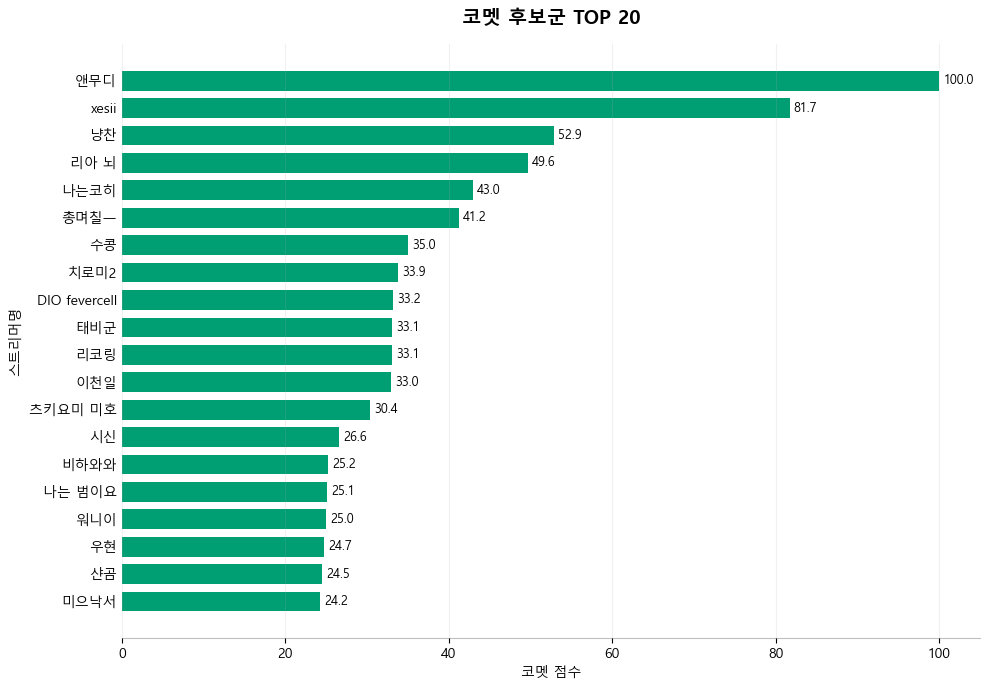

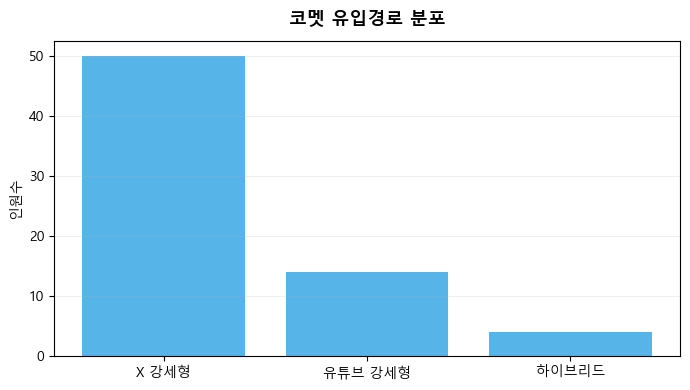

In [16]:
comet_top20 = comet_result[comet_result["코멧여부"] == 1].head(20)
draw_horizontal_bar(
    comet_top20,
    "스트리머명",
    "코멧score",
    "코멧 후보군 TOP 20",
    color="#009E73",
    xlabel="코멧 점수",
)

route_counts = comet_df[comet_df["코멧여부"] == 1]["코멧유입경로"].value_counts()
plt.figure(figsize=(7, 4), facecolor="white")
plt.bar(route_counts.index, route_counts.values, color="#56B4E9")
plt.title("코멧 유입경로 분포", fontsize=13, fontweight="bold", pad=12)
plt.ylabel("인원수")
plt.grid(axis="y", alpha=0.18)
plt.tight_layout()
plt.show()

## 8. 최종 결과 객체 정리

Run All 이후 아래 객체를 바로 활용할 수 있다.

- `proto_result`: 프로토스타 개인 후보 결과
- `supernova_result`: 슈퍼노바 개인 후보 결과
- `comet_result`: 코멧 개인 후보 결과
- `sat_result`: 위성/영입제한 개인 후보 결과
- `constellation_result`: 성단 소속/크루 결과
- `constellation_target15`: 성단 타겟 15팀 결과

In [17]:
final_outputs = {
    "성단": constellation_result.head(10),
    "프로토스타": proto_result.head(10),
    "위성": sat_result[sat_result["세그먼트_위성"] == "위성(Satellite)"].head(10),
    "슈퍼노바": supernova_result.head(10),
    "코멧": comet_result[comet_result["코멧여부"] == 1].head(10),
}

for name, output in final_outputs.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    display(output)

성단


,소속,멤버수,합계_뷰어십,합계_도네이션,합계_최고팔로워,플랫폼체급_점수,ARPU_점수,외부인기_점수,대중성_점수,영입우선_점수
0,이소로피아,3,189774,2852993,16378,54,72,64,84,100
1,리레볼루션,4,924754,5254413,118394,69,44,83,96,99
2,셀리브,6,38574,437206,11028,52,64,62,93,99
3,바라바라,6,56549,709730,9789,51,66,62,90,98
4,크레슈,4,136602,2787678,10624,53,81,52,71,96
5,오토메테일,4,35465,727658,4370,43,81,52,80,95
6,스테이브,4,56842,949190,6021,49,75,55,80,95
7,싸이코드,5,2629047,7951943,222916,79,28,87,94,94
8,이엔아이,4,18083,325094,3585,37,77,54,88,94
9,몽상컴퍼니,7,789706,8703730,39291,67,63,60,71,93


프로토스타


,스트리머명,소속,최고_팔로워,평균_시청자_최댓값,6분_최고채팅,뷰어십,팔로워대비_시청자,시간당_뷰어십,팬덤지수,프로토스타_score,프로토스타_구분
0,꽃분홍,NaN,1129,79,117,69927,6.997343,43.731707,-35.7,65.237884,S급 후보군
1,문이유,NaN,1326,69,1023,42698,5.203620,34.076616,-100.0,60.907132,S급 후보군
2,건망고,NaN,2648,74,372,58547,2.794562,29.142359,-3.5,60.384123,S급 후보군
3,라망,NaN,1817,60,447,69394,3.302146,30.529696,-29.1,59.386192,S급 후보군
4,세피람,NaN,1333,73,557,50964,5.476369,25.405783,-20.6,58.914269,S급 후보군
5,치즈냥,NaN,1854,60,587,58613,3.236246,31.077943,-21.8,58.896163,S급 후보군
6,백사라,NaN,851,55,578,62442,6.462985,32.037968,-25.1,58.889329,S급 후보군
7,다정현,NaN,2366,75,359,56352,3.169907,27.814413,-19.1,58.716162,S급 후보군
8,바또랑,이매방랑,1016,70,310,54596,6.889764,33.618227,-16.4,58.487231,S급 후보군
9,구름스무디,NaN,2681,78,470,65973,2.909362,13.807660,-48.5,57.935359,S급 후보군


위성


,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,소속,세그먼트_위성,위성점수
47,고여름,SOOP,gosummer,2025.01.01 ~ 2026.03.31,28244,2094,14206,7148,13617,7344,294293,781041,-4.8,-25.9,0,17200,1725,NaN,위성(Satellite),85.53
50,유시에,SOOP,sie4yu,2025.01.01 ~ 2026.03.31,16192,4044,7728,1211,12194,7189,647458,2578034,-30.2,-39.3,0,865,310,NaN,위성(Satellite),85.40
52,독케익,CHZZK,b68af124ae2f1743a1dcbf5e2ab41e0b,2025.01.01 ~ 2026.03.31,36004,3442,6659,1880,6748,3321,3998165,4905395,-6.3,-8.9,0,18500,12258,NaN,위성(Satellite),84.89
55,남궁혁,CHZZK,2cc562e9370970d567c1a25c5c7d0e77,2025.01.01 ~ 2026.03.31,34916,1102,3608,2436,17962,9705,926140,2085715,7.4,-8.9,0,75700,11927,NaN,위성(Satellite),84.66
58,엘시,CHZZK,6ccaebc2569f62344c6fc257f8f2b9ad,2025.07.18 ~ 2026.03.31,31686,1265,3303,921,12134,9420,1425457,2240704,8.1,-14.2,0,73100,6342,NaN,위성(Satellite),84.25
60,단즈,SOOP,danz59,2025.01.01 ~ 2026.03.31,30911,3569,17112,315,2951,1377,1167303,3321989,11.6,-14.0,0,103000,6349,NaN,위성(Satellite),84.15
61,단즈,SOOP,danz59,2025.01.01 ~ 2026.03.31,30911,3569,17112,315,2951,1377,1167303,3321989,11.6,-14.0,0,103000,6349,NaN,위성(Satellite),84.15
62,단즈,SOOP,danz59,2025.01.01 ~ 2026.03.31,30911,3569,17112,315,2951,1377,1167303,3321989,11.6,-14.0,0,103000,6349,NaN,위성(Satellite),84.15
63,단즈,SOOP,danz59,2025.01.01 ~ 2026.03.31,30911,3569,17112,315,2951,1377,1167303,3321989,11.6,-14.0,0,103000,6349,NaN,위성(Satellite),84.15
72,해리,SOOP,gofl2237,2025.01.01 ~ 2026.03.31,35258,6304,8021,638,7343,3382,1583202,2589526,-8.0,-22.6,0,15300,2868,NaN,위성(Satellite),83.80


슈퍼노바


,스트리머명,플랫폼,소속,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,유튜브_구독자,팬덤지수,뷰어십,대중성_score,팬덤체급_score,방송화력_score,슈퍼노바_score,슈퍼노바_구분
0,고세구,SOOP,이세계아이돌,199696,39102,5905590,95063,23877,8.2,545000,9.8,10855404,54.253498,79.165856,98.459542,71.533099,슈퍼노바 핵심 후보군
1,시라유키 히나,CHZZK,스텔라이브,219675,47218,6864206,6960,30958,2.6,302000,4.4,8608945,54.620978,76.791456,92.830024,69.715859,슈퍼노바 핵심 후보군
2,주르르,SOOP,이세계아이돌,175519,27415,3250999,55406,17295,7.2,417000,11.0,4794346,53.009609,76.514593,94.612701,69.286628,슈퍼노바 핵심 후보군
3,비챤,SOOP,이세계아이돌,176315,20891,2862540,108416,16694,5.2,331000,10.9,5657369,52.149919,76.276027,95.924277,69.125035,슈퍼노바 핵심 후보군
4,아카네 리제,CHZZK,스텔라이브,235506,40960,6069644,5873,23109,2.5,319000,3.9,5983879,54.326821,76.049127,91.230281,68.983262,슈퍼노바 핵심 후보군
5,탬탬버린,CHZZK,NaN,308659,23115,6876167,5923,13532,4.4,537000,-13.9,17075004,53.254149,79.331147,90.016164,68.963902,슈퍼노바 핵심 후보군
6,릴파,SOOP,이세계아이돌,185167,21790,5796867,13983,18865,7.0,434000,10.5,7788723,52.441361,77.770914,92.769388,68.855756,슈퍼노바 핵심 후보군
7,텐코 시부키,CHZZK,스텔라이브,222276,34645,6737178,7255,16465,-0.7,204000,4.1,14216251,53.596017,76.910885,91.058295,68.790304,슈퍼노바 핵심 후보군
8,유즈하 리코,CHZZK,스텔라이브,183957,36983,6609127,7092,21539,0.0,183000,5.6,6673506,53.523651,74.852816,91.730136,68.407563,슈퍼노바 핵심 후보군
9,아야츠노 유니,CHZZK,스텔라이브,281741,21414,6715398,6674,14086,1.7,347000,2.8,10770780,52.752609,77.650340,90.381397,68.384239,슈퍼노바 핵심 후보군


코멧


,스트리머명,플랫폼,소속,최고_팔로워,X_팔로워,유튜브_구독자,유튜브_유입지수,X_유입지수,코멧여부,코멧score,코멧유입경로
0,앤무디,CHZZK,NaN,11,3278,0,-100.0,3.257786,1,100.00,X 강세형
1,xesii,CHZZK,NaN,23,8060,1800,135.9,2.830283,1,81.71,하이브리드
2,냥찬,CHZZK,NaN,70,19669,10,-43.7,2.319398,1,52.87,X 강세형
3,리아 뇌,CHZZK,NaN,43,2878,2210,103.5,2.104862,1,49.65,하이브리드
4,나는코히,CHZZK,NaN,180,0,62000,112.3,0.000000,1,42.98,유튜브 강세형
5,총며칠ㅡ,CHZZK,NaN,237,0,91700,108.8,0.000000,1,41.24,유튜브 강세형
6,수콩,CHZZK,NaN,146,18088,0,-100.0,1.964371,1,35.03,X 강세형
7,치로미2,CHZZK,NaN,185,25398,0,-100.0,1.940864,1,33.85,X 강세형
8,DIO fevercell,CHZZK,NaN,439,121000,3850,35.6,1.922784,1,33.20,X 강세형
9,태비군,CHZZK,NaN,293,0,56900,92.6,0.000000,1,33.12,유튜브 강세형
